<a href="https://colab.research.google.com/github/akojo35/500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code/blob/main/Nigeria_Currency_Crisis_EWS_RandomForest%20(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**bold text**# Currency Crisis Early Warning Model — Nigerian Economy
## Random Forest Ensemble Classifier  |  1990–2023

**Author:** [Jamaladeen Abubakar]  
**Target:** Binary Currency Crisis (1 = Crisis, 0 = No Crisis)  
**Crisis Definition:** EMP index > μ + 1.5σ  OR  |ΔE/E| > 15%  OR  ΔR/R < −15%

---
### Notebook Sections
1. 📦 Install & Import Libraries  
2. 📊 Data Loading & Inspection  
3. 🔍 Exploratory Data Analysis (EDA)  
4. 📐 EMP Index Construction & Target Label  
5. ⚙️ Feature Engineering & Preprocessing  
6. 🌲 Random Forest Training & Hyperparameter Tuning  
7. 📈 Model Evaluation (AUC-ROC, F1, OOB Score)  
8. 🔎 SHAP Explainability & Feature Importance  
9. 🔄 Walk-Forward Cross-Validation  
10. 🚨 Early Warning Score & Policy Signals  
11. 📋 Summary Report  


In [ ]:
!git clone https://github.com/ajafuntua/Currency_Crises_Nigeria

Cloning into 'Currency_Crises_Nigeria'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 39 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 2.97 MiB | 6.83 MiB/s, done.
Resolving deltas: 100% (14/14), done.


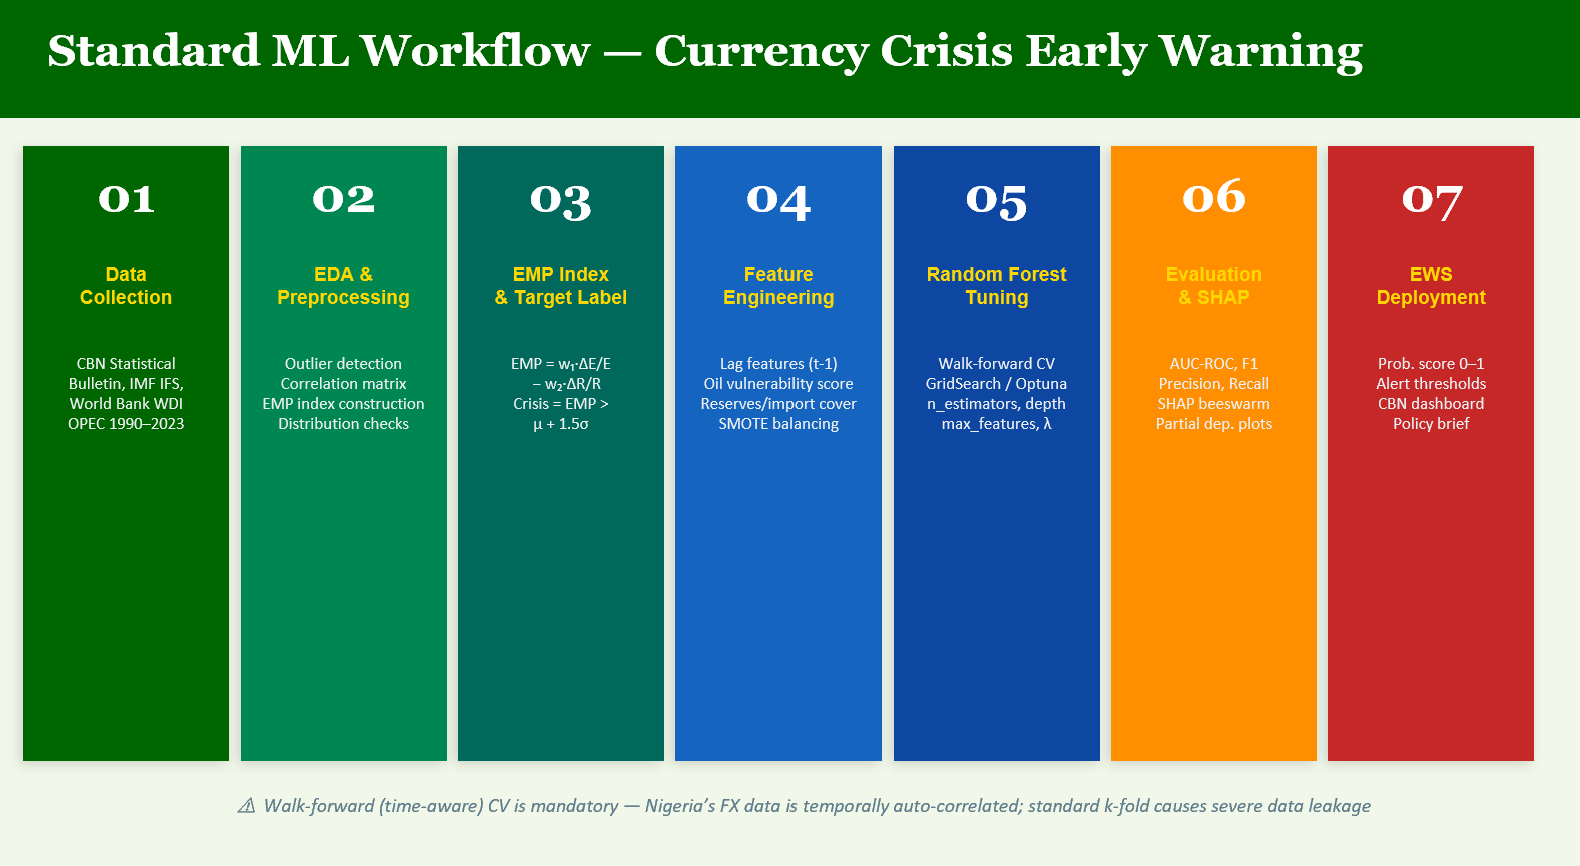

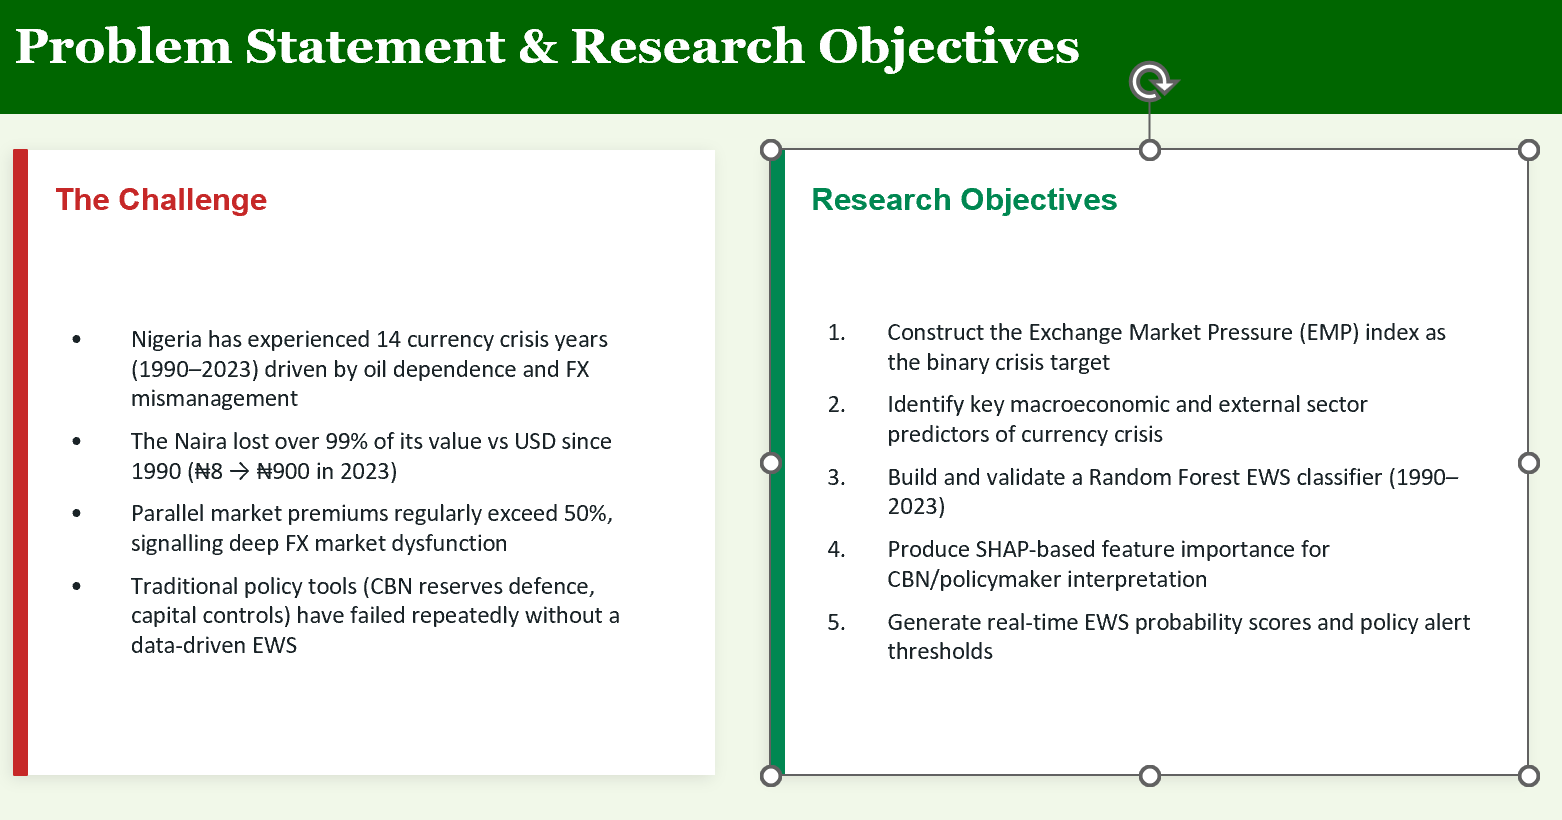

In [ ]:
!git clone https://github.com/ajafuntua/Currency_Crises_Nigeria

Cloning into 'Currency_Crises_Nigeria'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 39 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 2.97 MiB | 10.52 MiB/s, done.
Resolving deltas: 100% (14/14), done.


## 1. Install & Import Libraries

In [4]:
!git clone https://github.com/ajafuntua/Currency_Crises_Nigeria

Cloning into 'Currency_Crises_Nigeria'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 42 (delta 16), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 3.22 MiB | 8.52 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [5]:
!pwd

/content


In [6]:
# Install required packages (run once in Colab)
!pip install shap imbalanced-learn optuna --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.6 MB/s eta 0:00:00


In [7]:
# ── Core ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (TimeSeriesSplit, cross_val_score,
                                     GridSearchCV, RandomizedSearchCV, StratifiedKFold)
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, accuracy_score, confusion_matrix,
                              RocCurveDisplay, classification_report,
                              brier_score_loss, precision_recall_curve)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from scipy.stats import uniform, randint

# ── Imbalanced learning ───────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── SHAP ──────────────────────────────────────────────────────────────────────
import shap

# ── Hyperparameter search ─────────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})
NG_GREEN = '#008751'
NG_GOLD  = '#FFD700'
CRISIS_RED = '#C62828'

print("✅  All libraries loaded successfully")


✅  All libraries loaded successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Data Loading & Inspection

In [8]:
df = pd.read_excel("/content/Currency_Crises_Nigeria/Nigeria_Currency_Crisis_Dataset (1).xlsx", sheet_name = 'Nigeria_Currency_Crisis_Data', header = 3 )
df.head(3)

,Year,Exchange Rate,Exchange Rate Depreciation,Parallel Market Premium,Foreign Reserves,Reserves Change,Exchange Market Pressure Index,Current Account Balance,Trade Balance,Oil Revenue,...,GDP Growth Rate,Inflation Rate,M2 Money Supply Growth,Credit Growth,T-Bill Rate,Real Interest Rate,External Debt,Debt Service Ratio,Terms of Trade Change,Currency Crisis
0,1990,8.0,-3.5,2.5,3.8,8.2,-0.3,5.1,2.1,77.2,...,8.2,7.5,45.8,28.3,18.5,11.0,32.5,12.8,4.2,0
1,1991,9.9,23.8,5.1,3.5,-7.9,1.2,3.8,1.5,75.5,...,3.1,13.0,38.2,24.5,15.0,2.0,29.8,11.5,-3.5,0
2,1992,17.3,74.7,12.3,1.0,-71.4,5.8,-2.5,-0.8,72.8,...,2.3,44.5,55.8,38.5,24.5,-20.0,28.5,14.2,2.1,1


In [9]:
# ── Quick info & missing-value check ─────────────────────────────────────────
print("\n📋 Dataset Info:")
df.info()
print("\n❓ Missing values:", df.isnull().sum().sum())
print("\n📊 Descriptive Statistics:")
df.describe().round(2)



📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Year                            34 non-null     int64  
 1   Exchange Rate                   34 non-null     float64
 2   Exchange Rate Depreciation      34 non-null     float64
 3   Parallel Market Premium         34 non-null     float64
 4   Foreign Reserves                34 non-null     float64
 5   Reserves Change                 34 non-null     float64
 6   Exchange Market Pressure Index  34 non-null     float64
 7   Current Account Balance         34 non-null     float64
 8   Trade Balance                   34 non-null     float64
 9   Oil Revenue                     34 non-null     float64
 10  Oil Price                       34 non-null     float64
 11  GDP Growth Rate                 34 non-null     float64
 12  Inflation Rate       

,Year,Exchange Rate,Exchange Rate Depreciation,Parallel Market Premium,Foreign Reserves,Reserves Change,Exchange Market Pressure Index,Current Account Balance,Trade Balance,Oil Revenue,...,GDP Growth Rate,Inflation Rate,M2 Money Supply Growth,Credit Growth,T-Bill Rate,Real Interest Rate,External Debt,Debt Service Ratio,Terms of Trade Change,Currency Crisis
count,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,...,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00
mean,2006.50,179.69,20.19,25.93,23.97,14.90,2.06,0.16,0.49,72.50,...,3.65,18.29,25.45,23.68,15.57,-2.71,18.01,9.16,6.96,0.35
std,9.96,171.27,49.80,56.63,17.34,46.93,3.39,6.38,3.76,8.78,...,2.80,15.89,12.24,7.64,4.08,13.54,8.66,3.60,25.31,0.49
min,1990.00,8.00,-7.30,0.80,1.00,-71.40,-2.20,-15.50,-8.50,55.50,...,-1.80,5.40,12.50,12.80,9.50,-53.30,4.50,3.50,-48.50,0.00
25%,1998.25,86.18,0.08,3.28,7.15,-12.20,-0.15,-3.80,-1.20,65.35,...,2.05,9.25,17.23,18.50,13.00,-2.33,9.75,5.98,-5.00,0.00
50%,2006.50,130.65,5.20,5.65,28.30,0.30,1.20,1.15,0.35,74.80,...,3.60,12.95,22.50,22.50,14.35,1.50,18.50,8.85,1.45,0.00
75%,2014.75,187.02,20.23,23.98,38.60,37.98,3.32,4.20,2.72,78.50,...,6.25,17.67,28.50,28.45,18.50,4.05,22.72,11.50,27.48,1.00
max,2023.00,900.00,269.90,312.80,53.00,192.90,12.50,14.50,10.20,88.20,...,8.20,72.80,58.50,48.80,26.90,11.00,35.50,17.20,63.50,1.00


In [10]:
df.shape

(34, 21)

## 3. Exploratory Data Analysis (EDA)

In [ ]:
print(df.columns)

Index(['Year', 'Exchange Rate', 'Exchange Rate Depreciation',
       'Parallel Market Premium', 'Foreign Reserves', 'Reserves Change',
       'Exchange Market Pressure Index', 'Current Account Balance',
       'Trade Balance', 'Oil Revenue ', 'Oil Price', 'GDP Growth Rate',
       'Inflation Rate', 'M2 Money Supply Growth', 'Credit Growth',
       'T-Bill Rate', 'Real Interest Rate', 'External Debt',
       'Debt Service Ratio', 'Terms of Trade Change', 'Currency Crisis'],
      dtype='object')


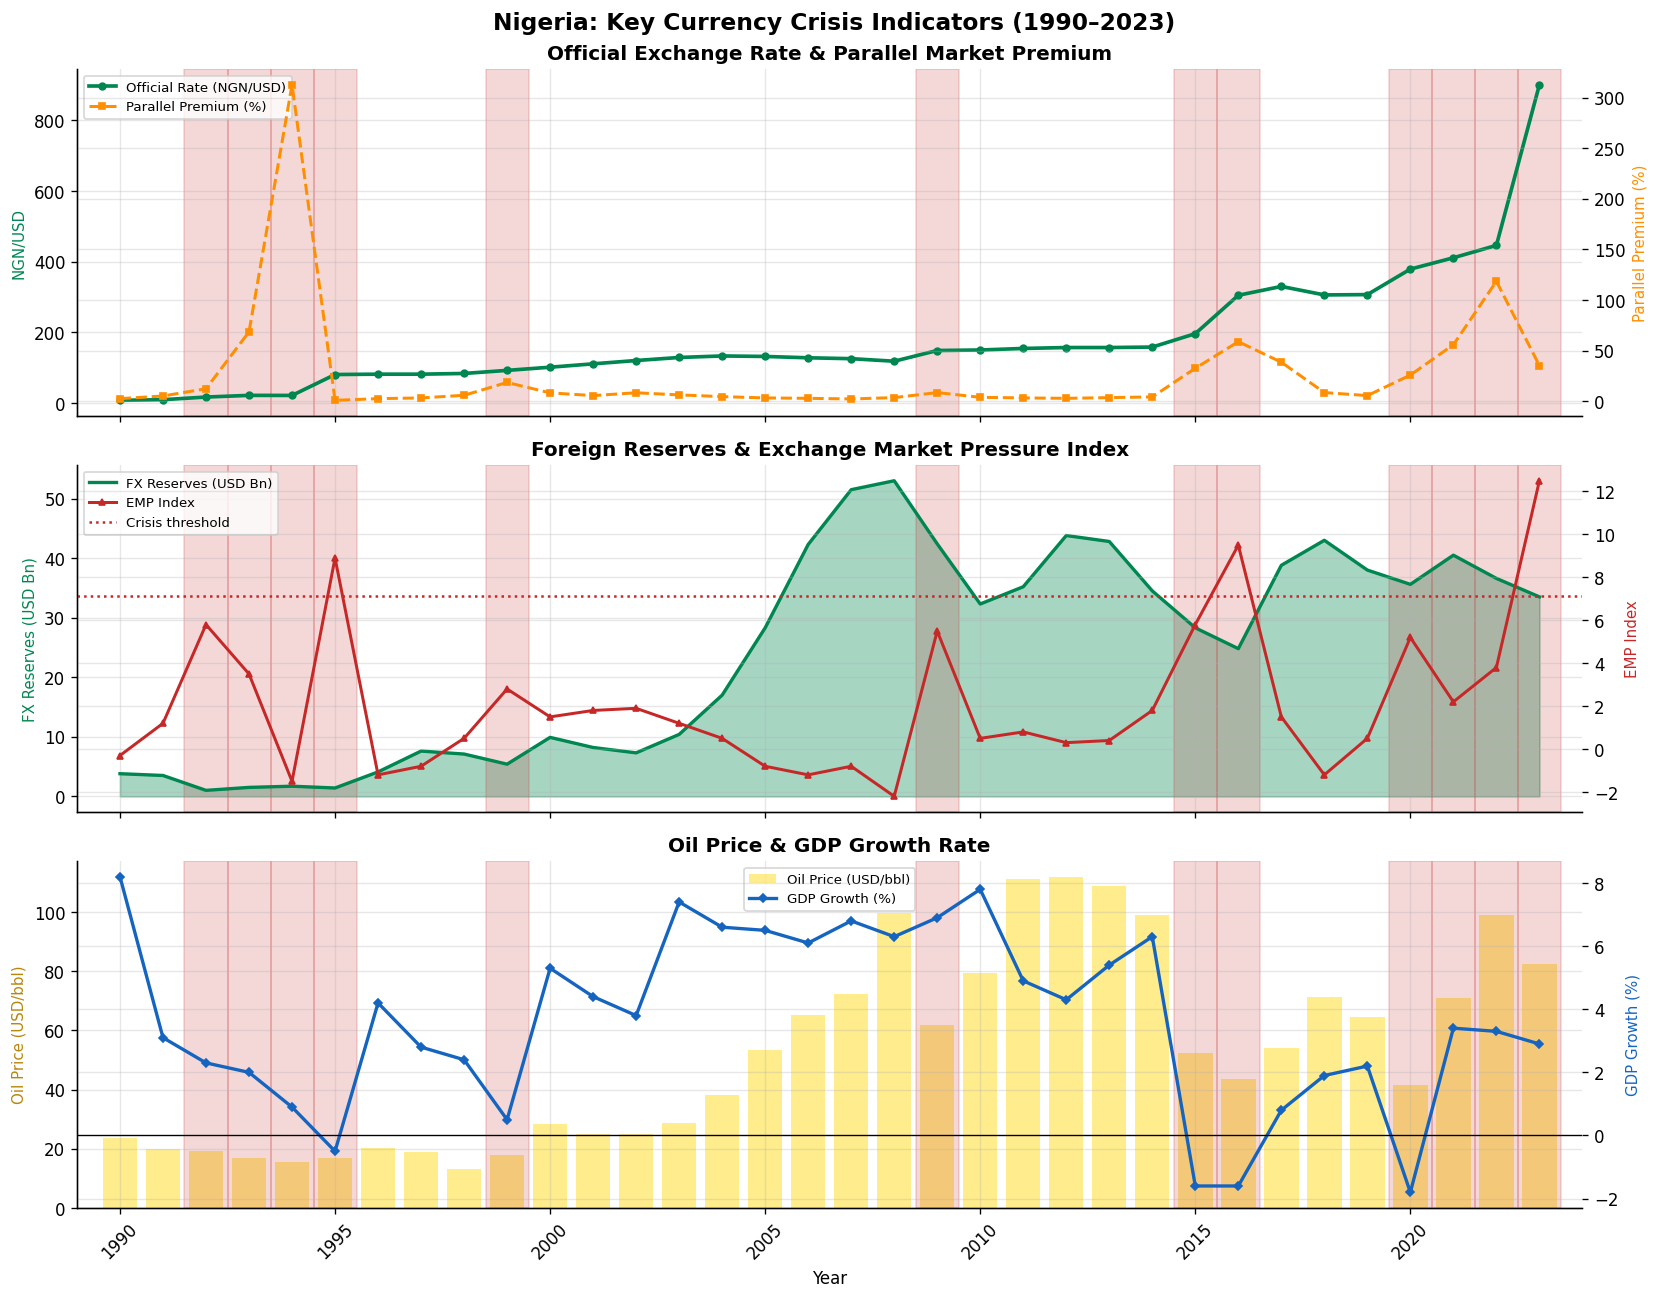

🔴 Red shading = currency crisis episodes


In [11]:
# ── 3.1 Exchange Rate & EMP Timeline ─────────────────────────────────────────

crisis_yrs = df.loc[df['Currency Crisis'] == 1, 'Year']


fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("Nigeria: Key Currency Crisis Indicators (1990–2023)",
             fontsize=14, fontweight='bold')

def shade(ax):
    for yr in crisis_yrs:
        ax.axvspan(yr-0.5, yr+0.5, alpha=0.18, color=CRISIS_RED)

# Plot 1: Exchange rate & parallel premium
ax1t = axes[0].twinx()
axes[0].plot(df['Year'], df['Exchange Rate'],   color=NG_GREEN, lw=2.2, marker='o', ms=4, label='Official Rate (NGN/USD)')
ax1t.plot(df['Year'], df['Parallel Market Premium'], color='#FF8F00', lw=1.8, ls='--', marker='s', ms=3.5, label='Parallel Premium (%)')
shade(axes[0])
axes[0].set_ylabel('NGN/USD', color=NG_GREEN, fontsize=9)
ax1t.set_ylabel('Parallel Premium (%)', color='#FF8F00', fontsize=9)
axes[0].set_title('Official Exchange Rate & Parallel Market Premium', fontweight='bold')
lines1, labs1 = axes[0].get_legend_handles_labels()
lines2, labs2 = ax1t.get_legend_handles_labels()
axes[0].legend(lines1+lines2, labs1+labs2, fontsize=8, loc='upper left')

# Plot 2: FX Reserves & EMP Index
ax2t = axes[1].twinx()
axes[1].fill_between(df['Year'], df['Foreign Reserves'], alpha=0.35, color=NG_GREEN)
axes[1].plot(df['Year'], df['Foreign Reserves'], color=NG_GREEN, lw=2, label='FX Reserves (USD Bn)')
ax2t.plot(df['Year'], df['Exchange Market Pressure Index'], color=CRISIS_RED, lw=1.8, marker='^', ms=4, label='EMP Index')
ax2t.axhline(df['Exchange Market Pressure Index'].mean() + 1.5*df['Exchange Market Pressure Index'].std(), color=CRISIS_RED, ls=':', lw=1.5, label='Crisis threshold')
shade(axes[1])
axes[1].set_ylabel('FX Reserves (USD Bn)', color=NG_GREEN, fontsize=9)
ax2t.set_ylabel('EMP Index', color=CRISIS_RED, fontsize=9)
axes[1].set_title('Foreign Reserves & Exchange Market Pressure Index', fontweight='bold')
l1,b1 = axes[1].get_legend_handles_labels()
l2,b2 = ax2t.get_legend_handles_labels()
axes[1].legend(l1+l2, b1+b2, fontsize=8)

# Plot 3: Oil price vs GDP growth
ax3t = axes[2].twinx()
axes[2].bar(df['Year'], df['Oil Price'], alpha=0.45, color=NG_GOLD, label='Oil Price (USD/bbl)')
ax3t.plot(df['Year'], df['GDP Growth Rate'], color='#1565C0', lw=2, marker='D', ms=3.5, label='GDP Growth (%)')
ax3t.axhline(0, color='black', lw=0.8)
shade(axes[2])
axes[2].set_ylabel('Oil Price (USD/bbl)', color='#B8860B', fontsize=9)
ax3t.set_ylabel('GDP Growth (%)', color='#1565C0', fontsize=9)
axes[2].set_title('Oil Price & GDP Growth Rate', fontweight='bold')
axes[2].set_xlabel('Year', fontsize=10)
l1,b1 = axes[2].get_legend_handles_labels()
l2,b2 = ax3t.get_legend_handles_labels()
axes[2].legend(l1+l2, b1+b2, fontsize=8)

for ax in axes:
    ax.set_xlim(1989, 2024)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('nigeria_eda_timeline.png', bbox_inches='tight', dpi=130)
plt.show()
print("🔴 Red shading = currency crisis episodes")


In [12]:
columns = ['Year', 'Exchange Rate', 'Exchange Rate Depreciation',
       'Parallel Market Premium', 'Foreign Reserves', 'Reserves Change',
       'Exchange Market Pressure Index', 'Current Account Balance',
       'Trade Balance', 'Oil Revenue ', 'Oil Price', 'GDP Growth Rate',
       'Inflation Rate', 'M2 Money Supply Growth', 'Credit Growth',
       'T-Bill Rate', 'Real Interest Rate', 'External Debt',
       'Debt Service Ratio', 'Terms of Trade Change', 'Currency Crisis']

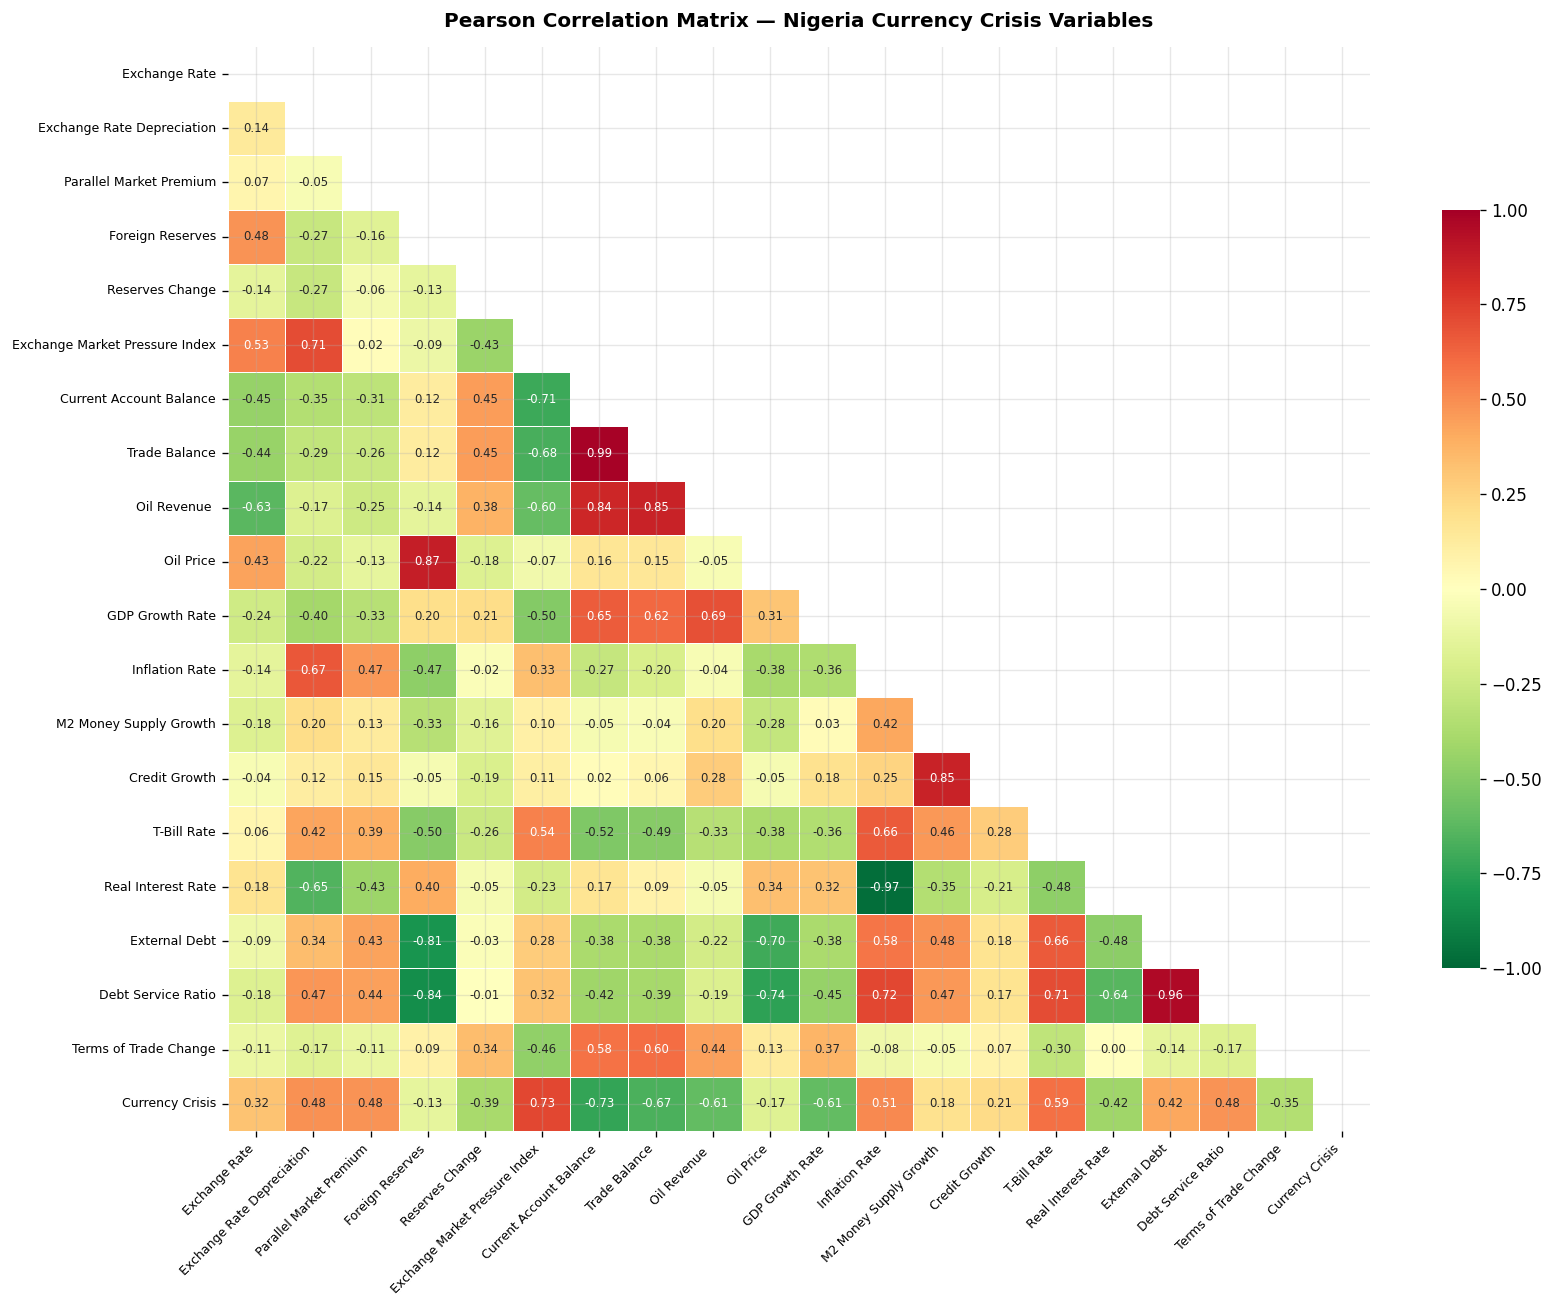


📊 Top correlates with Currency_Crisis (absolute):
Current Account Balance           0.734
Exchange Market Pressure Index    0.725
Trade Balance                     0.666
GDP Growth Rate                   0.605
Oil Revenue                       0.605
T-Bill Rate                       0.590
Inflation Rate                    0.509
Exchange Rate Depreciation        0.485
Debt Service Ratio                0.483
Parallel Market Premium           0.482
External Debt                     0.420
Real Interest Rate                0.420
Reserves Change                   0.385
Terms of Trade Change             0.350
Exchange Rate                     0.316
Credit Growth                     0.211
M2 Money Supply Growth            0.180
Oil Price                         0.167
Foreign Reserves                  0.126


In [13]:
# ── 3.2 Correlation heatmap ───────────────────────────────────────────────────
feat_cols = [c for c in df.columns if c not in ['Year']]
corr = df[feat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn_r', center=0,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.35, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink':0.7})
ax.set_title("Pearson Correlation Matrix — Nigeria Currency Crisis Variables",
             fontsize=12, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.savefig('nigeria_corr_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()

print("\n📊 Top correlates with Currency_Crisis (absolute):")
print(corr['Currency Crisis'].drop('Currency Crisis').abs()
      .sort_values(ascending=False).round(3).to_string())


In [ ]:
print(df.columns)

Index(['Year', 'Exchange Rate', 'Exchange Rate Depreciation',
       'Parallel Market Premium', 'Foreign Reserves', 'Reserves Change',
       'Exchange Market Pressure Index', 'Current Account Balance',
       'Trade Balance', 'Oil Revenue ', 'Oil Price', 'GDP Growth Rate',
       'Inflation Rate', 'M2 Money Supply Growth', 'Credit Growth',
       'T-Bill Rate', 'Real Interest Rate', 'External Debt',
       'Debt Service Ratio', 'Terms of Trade Change', 'Currency Crisis'],
      dtype='object')


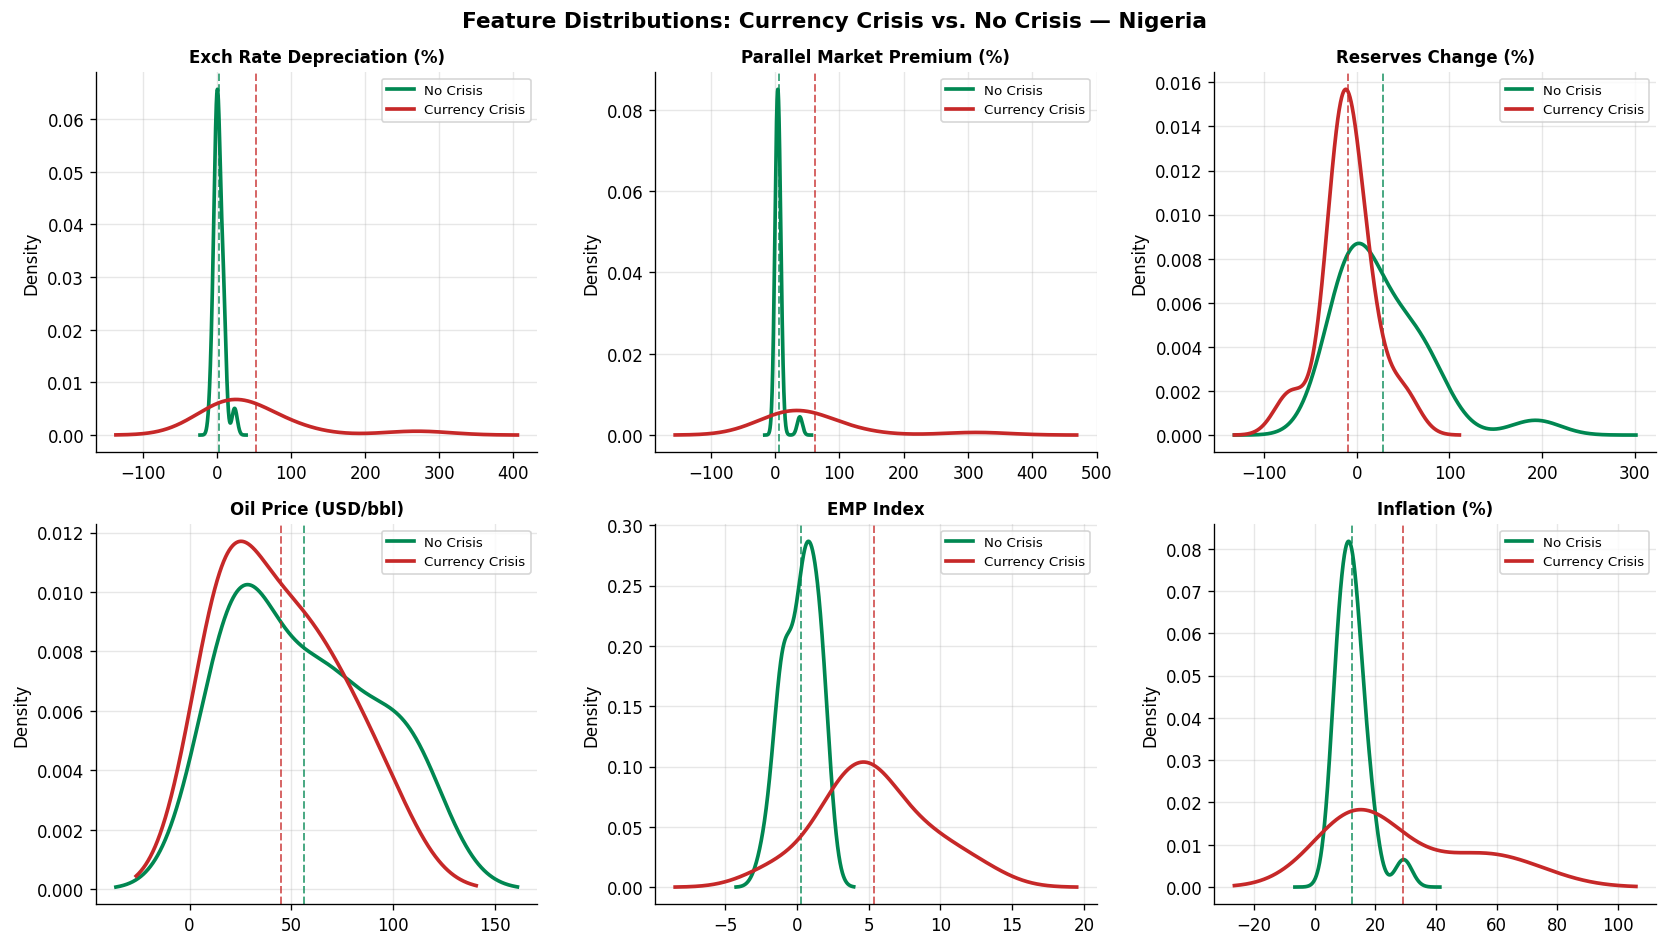

In [14]:
# ── 3.3 KDE plots: crisis vs no-crisis ───────────────────────────────────────
key_vars = ['Exchange Rate Depreciation','Parallel Market Premium','Reserves Change',
            'Oil Price','Exchange Market Pressure Index','Inflation Rate']
labels   = ['Exch Rate Depreciation (%)','Parallel Market Premium (%)',
            'Reserves Change (%)','Oil Price (USD/bbl)',
            'EMP Index','Inflation (%)']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Feature Distributions: Currency Crisis vs. No Crisis — Nigeria",
             fontsize=13, fontweight='bold')

for ax, var, lbl in zip(axes.flatten(), key_vars, labels):
    for val, color, name in [(0, NG_GREEN,'No Crisis'),(1, CRISIS_RED,'Currency Crisis')]:
        subset = df[df['Currency Crisis']==val][var]
        subset.plot.kde(ax=ax, color=color, lw=2.2, label=name)
        ax.axvline(subset.mean(), color=color, ls='--', lw=1.2, alpha=0.7)
    ax.set_title(lbl, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('nigeria_kde_plots.png', bbox_inches='tight', dpi=130)
plt.show()


## 4. EMP Index Construction & Target Label Verification

In [15]:
print(df.columns)

Index(['Year', 'Exchange Rate', 'Exchange Rate Depreciation',
       'Parallel Market Premium', 'Foreign Reserves', 'Reserves Change',
       'Exchange Market Pressure Index', 'Current Account Balance',
       'Trade Balance', 'Oil Revenue ', 'Oil Price', 'GDP Growth Rate',
       'Inflation Rate', 'M2 Money Supply Growth', 'Credit Growth',
       'T-Bill Rate', 'Real Interest Rate', 'External Debt',
       'Debt Service Ratio', 'Terms of Trade Change', 'Currency Crisis'],
      dtype='object')


In [16]:
# ── 4.1 Construct EMP index from components ───────────────────────────────────
# EMP_t = w1*(ΔE/E) − w2*(ΔR/R)
# Weights = inverse of standard deviation (precision weights)

delta_e = df['Exchange Rate Depreciation'].values        # % change in exchange rate
delta_r = df['Reserves Change'].values    # % change in reserves

w1 = 1 / delta_e.std()
w2 = 1 / delta_r.std()

emp_constructed = w1 * delta_e - w2 * delta_r
emp_mean   = emp_constructed.mean()
emp_std    = emp_constructed.std()
threshold  = emp_mean + 1.5 * emp_std

crisis_emp = (emp_constructed > threshold).astype(int)

df['emp_constructed'] = emp_constructed

print(f"EMP Statistics:")
print(f"  Mean    : {emp_mean:.4f}")
print(f"  Std Dev : {emp_std:.4f}")
print(f"  Crisis threshold (μ + 1.5σ) : {threshold:.4f}")
print(f"\nCrisis years by EMP rule    : {crisis_emp.sum()}")
print(f"Crisis years in dataset     : {df['Currency Crisis'].sum()}")

# Also flag by composite rule: |ΔE/E| > 15% OR ΔR/R < -15%
crisis_composite = ((np.abs(delta_e) > 15) | (delta_r < -15)).astype(int)
print(f"Crisis years by composite   : {crisis_composite.sum()}")
print(f"\nFinal target (dataset)  — Crisis years: {df['Currency Crisis'].sum()} | Non-crisis: {(df['Currency Crisis']==0).sum()}")


EMP Statistics:
  Mean    : 0.0891
  Std Dev : 1.5918
  Crisis threshold (μ + 1.5σ) : 2.4767

Crisis years by EMP rule    : 2
Crisis years in dataset     : 12
Crisis years by composite   : 13

Final target (dataset)  — Crisis years: 12 | Non-crisis: 22


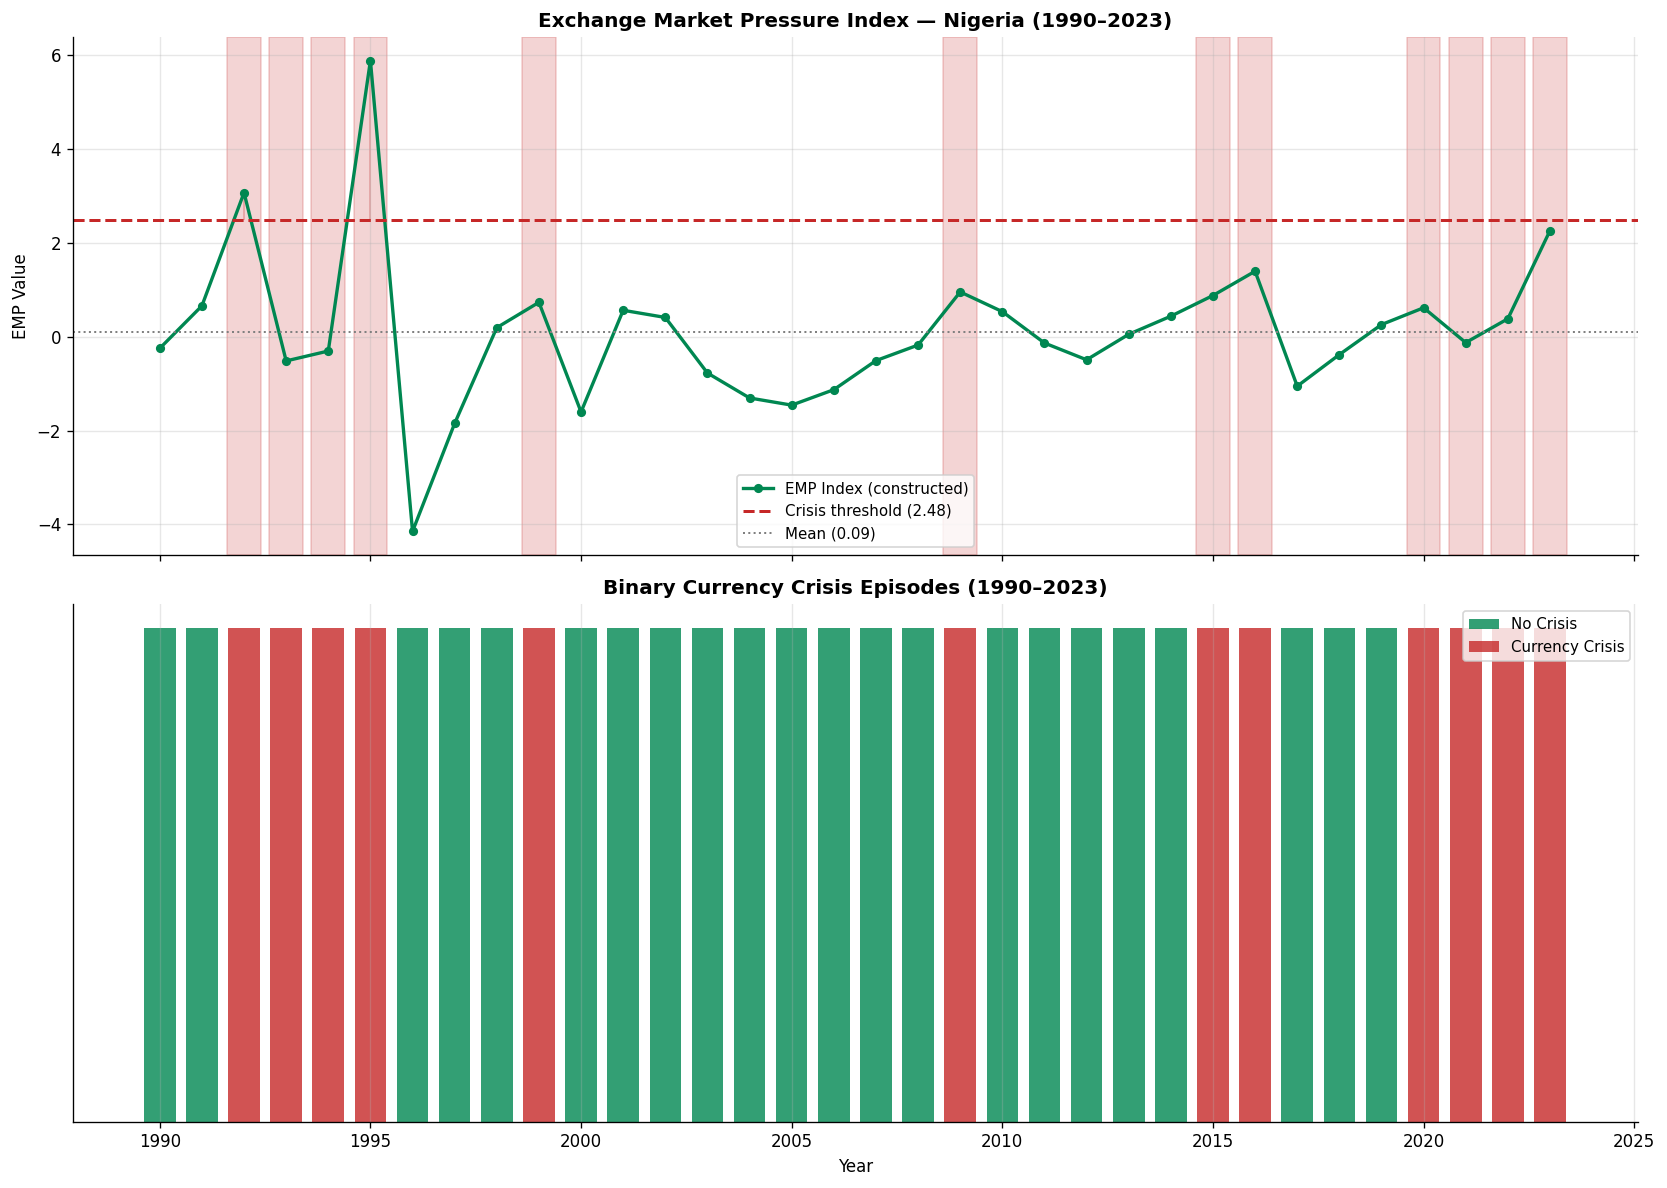

In [17]:
# ── 4.2 Visualise EMP and crisis episodes ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ── Panel 1: EMP Index ────────────────────────────────────────────────────────
axes[0].plot(df['Year'], df['emp_constructed'], color=NG_GREEN, lw=2, marker='o', ms=4.5, label='EMP Index (constructed)')
axes[0].axhline(threshold, color=CRISIS_RED, ls='--', lw=1.8, label=f'Crisis threshold ({threshold:.2f})')
axes[0].axhline(emp_mean,  color='grey', ls=':',  lw=1.2, label=f'Mean ({emp_mean:.2f})')
for yr in crisis_yrs:
    axes[0].axvspan(yr-0.4, yr+0.4, alpha=0.2, color=CRISIS_RED)
axes[0].fill_between(df['Year'], df['emp_constructed'], threshold,
                     where=emp_constructed > threshold, alpha=0.3, color=CRISIS_RED)
axes[0].set_ylabel('EMP Value', fontsize=10)
axes[0].set_title('Exchange Market Pressure Index — Nigeria (1990–2023)', fontweight='bold')
axes[0].legend(fontsize=9)

# ── Panel 2: Binary Crisis Indicator ─────────────────────────────────────────
crisis_mask     = df['Currency Crisis'] == 1
non_crisis_mask = df['Currency Crisis'] == 0

axes[1].bar(df['Year'][non_crisis_mask],
            [1] * non_crisis_mask.sum(),
            color=NG_GREEN, alpha=0.8, width=0.75, label='No Crisis')
axes[1].bar(df['Year'][crisis_mask],
            [1] * crisis_mask.sum(),
            color=CRISIS_RED, alpha=0.8, width=0.75, label='Currency Crisis')
axes[1].set_yticks([])
axes[1].set_xlabel('Year', fontsize=10)
axes[1].set_title('Binary Currency Crisis Episodes (1990–2023)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('nigeria_emp_crisis.png', bbox_inches='tight', dpi=130)
plt.show()

## 5. Feature Engineering & Preprocessing

In [18]:
print(df.columns)

Index(['Year', 'Exchange Rate', 'Exchange Rate Depreciation',
       'Parallel Market Premium', 'Foreign Reserves', 'Reserves Change',
       'Exchange Market Pressure Index', 'Current Account Balance',
       'Trade Balance', 'Oil Revenue ', 'Oil Price', 'GDP Growth Rate',
       'Inflation Rate', 'M2 Money Supply Growth', 'Credit Growth',
       'T-Bill Rate', 'Real Interest Rate', 'External Debt',
       'Debt Service Ratio', 'Terms of Trade Change', 'Currency Crisis',
       'emp_constructed'],
      dtype='object')


In [19]:
# ── 5.1 Engineer additional features ─────────────────────────────────────────
df_fe = df.copy()

# Lag features (t-1): EWS needs leading indicators
lag_vars = ['Exchange Rate Depreciation','Parallel Market Premium','Foreign Reserves',
            'Reserves Change','Exchange Market Pressure Index','Oil Price','Inflation Rate',
            'M2 Money Supply Growth']
for col in lag_vars:
    df_fe[f'{col}_lag1'] = df_fe[col].shift(1)
    df_fe[f'{col}_lag2'] = df_fe[col].shift(2)

# Oil vulnerability score (combined oil dependence + oil price signal)
df_fe['Oil_Vulnerability'] = (df_fe['Oil Revenue '] / 100) * (1 / (df_fe['Oil Price'] + 1e-6))

# Import cover ratio (reserves in months of imports proxy)
df_fe['Import_Cover_Proxy'] = df_fe['Foreign Reserves'] / (np.abs(df_fe['Trade Balance']) + 0.1)

# Currency over-valuation proxy (real rate signal)
df_fe['RER_Misalignment'] = df_fe['Inflation Rate'] - df_fe['Exchange Rate Depreciation']

# Monetary pressure index
df_fe['MonPressure'] = df_fe['M2 Money Supply Growth'] - df_fe['GDP Growth Rate']

# EMP momentum
df_fe['EMP_Change'] = df_fe['Exchange Market Pressure Index'].diff()

# Reserve adequacy gap (below 3-month rule)
df_fe['Reserves_Gap'] = 3.0 - df_fe['Import_Cover_Proxy']

# Drop NaN rows from lag operations
df_fe.dropna(inplace=True)
df_fe.reset_index(drop=True, inplace=True)

print(f"Dataset after feature engineering: {df_fe.shape}")
print(f"Total features available       : {df_fe.shape[1] - 2}  (excl. Year & target)")


Dataset after feature engineering: (32, 44)
Total features available       : 42  (excl. Year & target)


In [ ]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 43 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 32 non-null     int64  
 1   Exchange Rate                        32 non-null     float64
 2   Exchange Rate Depreciation           32 non-null     float64
 3   Parallel Market Premium              32 non-null     float64
 4   Foreign Reserves                     32 non-null     float64
 5   Reserves Change                      32 non-null     float64
 6   Exchange Market Pressure Index       32 non-null     float64
 7   Current Account Balance              32 non-null     float64
 8   Trade Balance                        32 non-null     float64
 9   Oil Revenue                          32 non-null     float64
 10  Oil Price                            32 non-null     float64
 11  GDP Growth Rate                   

In [20]:
# ── 5.2 Define X and y ────────────────────────────────────────────────────────
feature_cols = [c for c in df_fe.columns if c not in ['Year','Currency Crisis']]

X = df_fe[feature_cols].values
y = df_fe['Currency Crisis'].values

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}  →  Crisis: {y.sum()} | No-Crisis: {(y==0).sum()}")
print(f"\nAll {len(feature_cols)} features:")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {f}")


Feature matrix X : (32, 42)
Target vector  y : (32,)  →  Crisis: 12 | No-Crisis: 20

All 42 features:
   1. Exchange Rate
   2. Exchange Rate Depreciation
   3. Parallel Market Premium
   4. Foreign Reserves
   5. Reserves Change
   6. Exchange Market Pressure Index
   7. Current Account Balance
   8. Trade Balance
   9. Oil Revenue 
  10. Oil Price
  11. GDP Growth Rate
  12. Inflation Rate
  13. M2 Money Supply Growth
  14. Credit Growth
  15. T-Bill Rate
  16. Real Interest Rate
  17. External Debt
  18. Debt Service Ratio
  19. Terms of Trade Change
  20. emp_constructed
  21. Exchange Rate Depreciation_lag1
  22. Exchange Rate Depreciation_lag2
  23. Parallel Market Premium_lag1
  24. Parallel Market Premium_lag2
  25. Foreign Reserves_lag1
  26. Foreign Reserves_lag2
  27. Reserves Change_lag1
  28. Reserves Change_lag2
  29. Exchange Market Pressure Index_lag1
  30. Exchange Market Pressure Index_lag2
  31. Oil Price_lag1
  32. Oil Price_lag2
  33. Inflation Rate_lag1
  34. Infl

In [21]:
df_fe.shape

(32, 44)

In [22]:
# ── 5.3 Scale features ────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 5.4 SMOTE to handle class imbalance ──────────────────────────────────────
smote    = SMOTE(random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(X_scaled, y)
print(f"After SMOTE resampling:  Crisis={y_res.sum()}  |  No-Crisis={(y_res==0).sum()}")

# ── 5.5 Class weight ratio (alternative to SMOTE) ────────────────────────────
ratio = (y == 0).sum() / (y == 1).sum()
print(f"Class weight ratio for class_weight param: {ratio:.2f}")


After SMOTE resampling:  Crisis=20  |  No-Crisis=20
Class weight ratio for class_weight param: 1.67


## 6. Random Forest Training & Hyperparameter Tuning

In [23]:
RandomForestClassifier()

RandomForestClassifier()

In [24]:
# ── 6.1 Baseline Random Forest ────────────────────────────────────────────────
rf_base = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = None,
    max_features    = 'sqrt',
    min_samples_leaf= 1,
    class_weight    = 'balanced',
    oob_score       = True,
    random_state    = 42,
    n_jobs          = -1,
)
rf_base.fit(X_scaled, y)
y_pred_base  = rf_base.predict(X_scaled)
y_proba_base = rf_base.predict_proba(X_scaled)[:, 1]

print("Baseline Random Forest — Training Performance")
print("=" * 48)
print(f"  OOB Score  : {rf_base.oob_score_:.4f}")
print(f"  AUC-ROC    : {roc_auc_score(y, y_proba_base):.4f}")
print(f"  F1-Score   : {f1_score(y, y_pred_base):.4f}")
print(f"  Accuracy   : {accuracy_score(y, y_pred_base):.4f}")
print("\nNote: High in-sample scores expected; CV scores are more meaningful.")


Baseline Random Forest — Training Performance
  OOB Score  : 0.9375
  AUC-ROC    : 1.0000
  F1-Score   : 1.0000
  Accuracy   : 1.0000

Note: High in-sample scores expected; CV scores are more meaningful.


In [ ]:
### Option A: GridSearchCV
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [3, 5, 7, 10, None],
    'max_features'      : ['sqrt', 'log2', 0.5],
    'min_samples_leaf'  : [1, 2, 4],
    'min_samples_split' : [2, 5, 10],
}

grid_search = GridSearchCV(
    estimator          = rf_base,
    param_grid         = param_grid,
    cv                 = tscv,
    scoring            = 'roc_auc',
    n_jobs             = -1,
    verbose            = 1,
    refit              = True,
    return_train_score = True,
)

print("🔍 Running GridSearchCV ...")
grid_search.fit(X_scaled, y)

print(f"\n✅ Best CV AUC-ROC : {grid_search.best_score_:.4f}")
print(f"\nBest parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<22} : {v}")

rf_grid_best = grid_search.best_estimator_
y_pred_grid  = rf_grid_best.predict(X_scaled)
y_proba_grid = rf_grid_best.predict_proba(X_scaled)[:, 1]

print("\nFinal Random Forest — Training Performance (GridSearchCV)")
print("=" * 55)
print(classification_report(y, y_pred_grid,
      target_names=['No Crisis', 'Currency Crisis']))


🔍 Running GridSearchCV ...
Fitting 5 folds for each of 540 candidates, totalling 2700 fits


In [ ]:

### Option B: RandomizedSearchCV
param_dist = {
    'n_estimators'         : randint(50, 600),
    'max_depth'            : randint(2, 15),
    'max_features'         : uniform(0.1, 0.9),     # fraction 0.1 – 1.0
    'min_samples_leaf'     : randint(1, 10),
    'min_samples_split'    : randint(2, 15),
    'max_samples'          : uniform(0.5, 0.5),     # bootstrap fraction 0.5 – 1.0
    'min_impurity_decrease': uniform(0.0, 0.05),
}

rand_search = RandomizedSearchCV(
    estimator           = rf_base,
    param_distributions = param_dist,
    n_iter              = 80,           # 80 random draws — fast & effective
    cv                  = tscv,
    scoring             = 'roc_auc',
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1,
    refit               = True,
)

print("🔍 Running RandomizedSearchCV ...")
rand_search.fit(X_scaled, y)

print(f"\n✅ Best CV AUC-ROC : {rand_search.best_score_:.4f}")
print(f"\nBest parameters:")
for k, v in rand_search.best_params_.items():
    print(f"  {k:<22} : {v}")

rf_rand_best = rand_search.best_estimator_
y_pred_rand  = rf_rand_best.predict(X_scaled)
y_proba_rand = rf_rand_best.predict_proba(X_scaled)[:, 1]

print("\nFinal Random Forest — Training Performance (RandomizedSearchCV)")
print("=" * 55)
print(classification_report(y, y_pred_rand,
      target_names=['No Crisis', 'Currency Crisis']))


🔍 Running RandomizedSearchCV ...
Fitting 5 folds for each of 80 candidates, totalling 400 fits

✅ Best CV AUC-ROC : nan

Best parameters:
  max_depth              : 8
  max_features           : 0.8168886881742096
  max_samples            : 0.5917173949330818
  min_impurity_decrease  : 0.038984550013638465
  min_samples_leaf       : 5
  min_samples_split      : 8
  n_estimators           : 171

Final Random Forest — Training Performance (RandomizedSearchCV)
                 precision    recall  f1-score   support

      No Crisis       1.00      1.00      1.00        20
Currency Crisis       1.00      1.00      1.00        12

       accuracy                           1.00        32
      macro avg       1.00      1.00      1.00        32
   weighted avg       1.00      1.00      1.00        32



In [ ]:
# ── Option C: Bayesian Hyperparameter Optimisation (Optuna) ────────────────────────
tscv = TimeSeriesSplit(n_splits=5)

def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators',   100, 600),
        'max_depth'       : trial.suggest_int('max_depth',        3,  20),
        'max_features'    : trial.suggest_categorical('max_features', ['sqrt','log2', 0.5, 0.7]),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1,   8),
        'min_samples_split': trial.suggest_int('min_samples_split',2, 10),
        'class_weight'    : 'balanced',
        'oob_score'       : False,
        'random_state'    : 42,
        'n_jobs'          : -1,
    }
    model  = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_scaled, y, cv=tscv,
                             scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=140, show_progress_bar=True)

print(f"✅  Best AUC-ROC (CV) : {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k:<22} : {v}")


In [ ]:
### 6.3 Train Final Model with Best Parameters

# ── Pick the winner ──────────────────────────────────────────────────────────
if rand_search.best_score_ >= grid_search.best_score_:
    best_params = rand_search.best_params_.copy()
    best_score  = rand_search.best_score_
    method_name = "RandomizedSearchCV"
else:
    best_params = grid_search.best_params_.copy()
    best_score  = grid_search.best_score_
    method_name = "GridSearchCV"

print(f"🏆 Winner : {method_name}  |  Best CV AUC-ROC : {best_score:.4f}")

# ── Build final parameter set ────────────────────────────────────────────────
final_params = best_params.copy()
final_params.update({
    'class_weight' : 'balanced',
    'oob_score'    : True,       # re-enabled for unbiased OOB estimate
    'random_state' : 42,
    'n_jobs'       : -1,
})

print(f"\nFinal model parameters ({method_name}):")
for k, v in sorted(final_params.items()):
    val = f"{v:.5f}" if isinstance(v, float) else str(v)
    print(f"  {k:<26} : {val}")


🏆 Winner : GridSearchCV  |  Best CV AUC-ROC : nan

Final model parameters (GridSearchCV):
  class_weight               : balanced
  max_depth                  : 3
  max_features               : sqrt
  min_samples_leaf           : 1
  min_samples_split          : 2
  n_estimators               : 100
  n_jobs                     : -1
  oob_score                  : True
  random_state               : 42


In [ ]:
# ── 6.3 Train final model with best parameters using OPTUNA ───────────────────────────────
best_params = study.best_params.copy()
best_params.update({ 'class_weight':'balanced', 'oob_score':True, 'random_state':42, 'n_jobs':-1 })

rf_final = RandomForestClassifier(**best_params)
rf_final.fit(X_scaled, y)

y_pred  = rf_final.predict(X_scaled)
y_proba = rf_final.predict_proba(X_scaled)[:, 1]

print("Final Random Forest — Training Report")
print("=" * 48)
print(f"  OOB Score  : {rf_final.oob_score_:.4f}")
print()
print(classification_report(y, y_pred, target_names=['No Crisis','Currency Crisis']))


## 7. Model Evaluation

In [ ]:


# ── 6.1  Random Forest Final ────────────────────────────────────────────────
rf_final = RandomForestClassifier(
    n_estimators    = 100,
    max_depth       = 3,
    max_features    = 'sqrt',
    min_samples_leaf= 1,
    class_weight    = 'balanced',
    oob_score       = True,
    random_state    = 42,

)
rf_final.fit(X_scaled, y)
y_pred_final  = rf_final.predict(X_scaled)
y_proba_final = rf_final.predict_proba(X_scaled)[:, 1]

print(" Random Forest Final — Best Performance")
print("=" * 48)
print(f"  OOB Score  : {rf_final.oob_score_:.4f}")
print(f"  AUC-ROC    : {roc_auc_score(y, y_proba_final):.4f}")
print(f"  F1-Score   : {f1_score(y, y_pred_final):.4f}")
print(f"  Accuracy   : {accuracy_score(y, y_pred_final):.4f}")
print("\nNote: High in-sample scores expected; CV scores are more meaningful.")

 Random Forest Final — Best Performance
  OOB Score  : 0.8750
  AUC-ROC    : 1.0000
  F1-Score   : 1.0000
  Accuracy   : 1.0000

Note: High in-sample scores expected; CV scores are more meaningful.


In [ ]:
# ── 7.1 Walk-Forward CV comparison across algorithms ────────────────────────
print("🔄  Walk-Forward Cross-Validation (TimeSeriesSplit, n=5)")
print("=" * 58)

models = {
    'Random Forest (Tuned)' : rf_final,
    'Gradient Boosting'     : GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                max_depth=3, random_state=42),
    'Logistic Regression'   : LogisticRegression(class_weight='balanced', max_iter=500, random_state=42),
    'Decision Tree'         : DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42),
    'K-Nearest Neighbours'  : KNeighborsClassifier(n_neighbors=5),
}

results = {}
for name, model in models.items():
    auc  = cross_val_score(model, X_scaled, y, cv=tscv, scoring='roc_auc').mean()
    f1   = cross_val_score(model, X_scaled, y, cv=tscv, scoring='f1').mean()
    rec  = cross_val_score(model, X_scaled, y, cv=tscv, scoring='recall').mean()
    prec = cross_val_score(model, X_scaled, y, cv=tscv, scoring='precision').mean()
    results[name] = {'AUC-ROC':auc, 'F1-Score':f1, 'Recall':rec, 'Precision':prec}
    print(f"  {name:<26} AUC={auc:.3f}  F1={f1:.3f}  Recall={rec:.3f}  Prec={prec:.3f}")

results_df = pd.DataFrame(results).T.round(3)
print()
print(results_df.to_string())


🔄  Walk-Forward Cross-Validation (TimeSeriesSplit, n=5)
  Random Forest (Tuned)      AUC=nan  F1=0.333  Recall=0.300  Prec=0.400
  Gradient Boosting          AUC=nan  F1=0.271  Recall=0.250  Prec=0.300
  Logistic Regression        AUC=nan  F1=0.371  Recall=0.350  Prec=0.400
  Decision Tree              AUC=nan  F1=0.411  Recall=0.500  Prec=0.360
  K-Nearest Neighbours       AUC=nan  F1=0.213  Recall=0.300  Prec=0.250

                       AUC-ROC  F1-Score  Recall  Precision
Random Forest (Tuned)      NaN     0.333    0.30       0.40
Gradient Boosting          NaN     0.271    0.25       0.30
Logistic Regression        NaN     0.371    0.35       0.40
Decision Tree              NaN     0.411    0.50       0.36
K-Nearest Neighbours       NaN     0.213    0.30       0.25


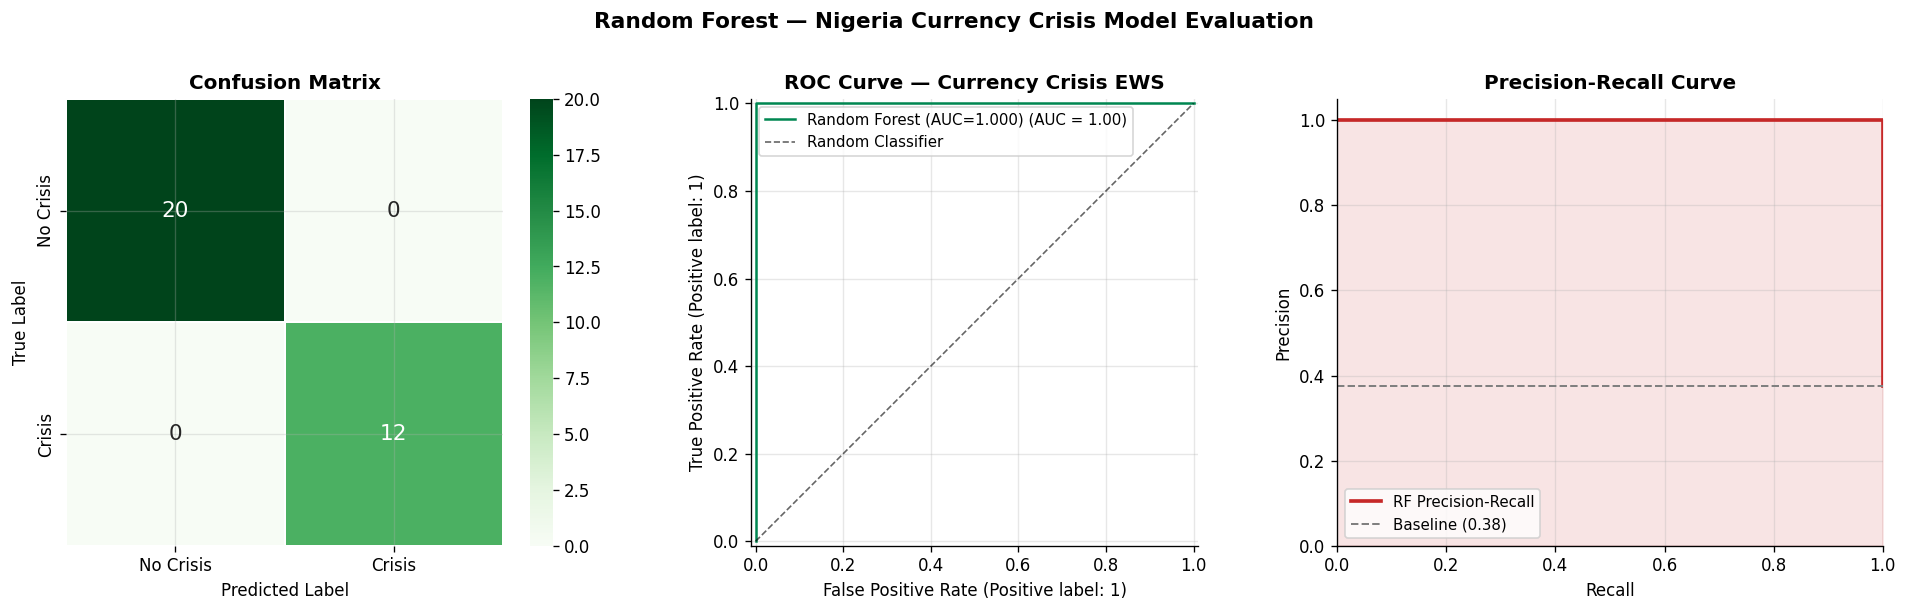


📈 Key Metrics (Full Training Set):
  OOB Score  : 0.8750
  AUC-ROC    : 1.0000
  F1-Score   : 1.0000
  Recall     : 1.0000
  Precision  : 1.0000
  Brier Score: 0.0103


In [ ]:
# ── 7.2 Confusion Matrix + ROC Curve + Precision-Recall ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Crisis','Crisis'],
            yticklabels=['No Crisis','Crisis'],
            ax=axes[0], linewidths=1.2, linecolor='white',
            annot_kws={'size':13})
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=12)
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

# 2. ROC Curve
RocCurveDisplay.from_predictions(y, y_proba_final, ax=axes[1],
    color=NG_GREEN, name=f'Random Forest (AUC={roc_auc_score(y, y_proba_final):.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, alpha=0.6, label='Random Classifier')
axes[1].set_title('ROC Curve — Currency Crisis EWS', fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9)

# 3. Precision-Recall curve
prec_vals, rec_vals, thresholds = precision_recall_curve(y, y_proba_final)
axes[2].plot(rec_vals, prec_vals, color=CRISIS_RED, lw=2.2, label='RF Precision-Recall')
axes[2].fill_between(rec_vals, prec_vals, alpha=0.12, color=CRISIS_RED)
axes[2].axhline(y.mean(), color='grey', ls='--', lw=1.2, label=f'Baseline ({y.mean():.2f})')
axes[2].set_xlabel('Recall', fontsize=10); axes[2].set_ylabel('Precision', fontsize=10)
axes[2].set_title('Precision-Recall Curve', fontweight='bold', fontsize=12)
axes[2].legend(fontsize=9)
axes[2].set_xlim(0,1); axes[2].set_ylim(0,1.05)

plt.suptitle("Random Forest — Nigeria Currency Crisis Model Evaluation", fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('nigeria_model_evaluation.png', bbox_inches='tight', dpi=130)
plt.show()

print(f"\n📈 Key Metrics (Full Training Set):")
print(f"  OOB Score  : {rf_final.oob_score_:.4f}")
print(f"  AUC-ROC    : {roc_auc_score(y, y_proba_final):.4f}")
print(f"  F1-Score   : {f1_score(y, y_pred_final):.4f}")
print(f"  Recall     : {recall_score(y, y_pred_final):.4f}")
print(f"  Precision  : {precision_score(y, y_pred_final):.4f}")
print(f"  Brier Score: {brier_score_loss(y, y_proba_final):.4f}")


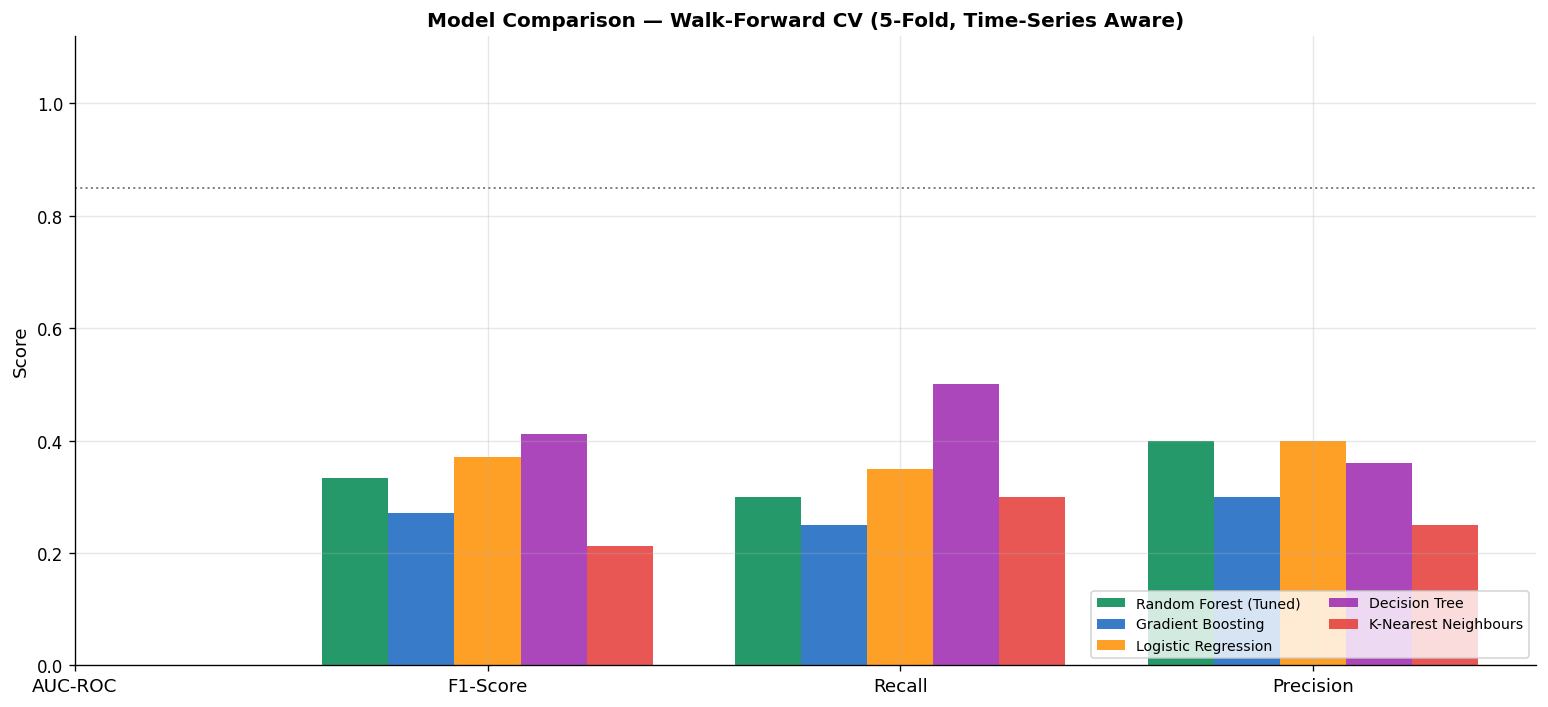

In [ ]:
# ── 7.3 Model comparison bar chart ───────────────────────────────────────────
metric_names = ['AUC-ROC','F1-Score','Recall','Precision']
x = np.arange(len(metric_names))
width = 0.16
colors = [NG_GREEN,'#1565C0','#FF8F00','#9C27B0','#E53935']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metric_names]
    ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width*2)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison — Walk-Forward CV (5-Fold, Time-Series Aware)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8.5, loc='lower right', ncol=2)
ax.axhline(0.85, color='grey', ls=':', lw=1.2, label='Target AUC')
plt.tight_layout()
plt.savefig('nigeria_model_comparison.png', bbox_inches='tight', dpi=130)
plt.show()


## 8. SHAP Explainability & Feature Importance

In [ ]:
sv_crisis

array([[[ 0.00132962, -0.00132962],
        [-0.03700634,  0.03700634],
        [-0.04468348,  0.04468348],
        ...,
        [-0.00843421,  0.00843421],
        [-0.04686909,  0.04686909],
        [ 0.00380314, -0.00380314]],

       [[ 0.00125208, -0.00125208],
        [-0.03342036,  0.03342036],
        [-0.09931591,  0.09931591],
        ...,
        [-0.01166648,  0.01166648],
        [ 0.0169777 , -0.0169777 ],
        [ 0.00349064, -0.00349064]],

       [[ 0.00125208, -0.00125208],
        [ 0.03632284, -0.03632284],
        [-0.09250198,  0.09250198],
        ...,
        [-0.01637578,  0.01637578],
        [ 0.01828148, -0.01828148],
        [ 0.00320762, -0.00320762]],

       ...,

       [[-0.03085874,  0.03085874],
        [ 0.01737247, -0.01737247],
        [-0.10433326,  0.10433326],
        ...,
        [ 0.00444837, -0.00444837],
        [ 0.01553431, -0.01553431],
        [ 0.00551145, -0.00551145]],

       [[-0.01991758,  0.01991758],
        [ 0.01449969, -0.01

In [ ]:
# ── Compute SHAP values ───────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_scaled)

# ── Version-safe extraction of class-1 (crisis) SHAP values ──────────────────
# Old SHAP (< 0.41) : shap_values is a list → [class_0_array, class_1_array]
# New SHAP (≥ 0.41) : shap_values is a 3-D array → shape (samples, features, classes)
if isinstance(shap_values, list):
    sv_crisis = shap_values[1]           # old API
elif shap_values.ndim == 3:
    sv_crisis = shap_values[:, :, 1]     # new API  ← your case: shape (32, 41, 2)
else:
    sv_crisis = shap_values              # single-output fallback

print(f"SHAP raw shape  : {np.array(shap_values).shape}")
print(f"sv_crisis shape : {sv_crisis.shape}")   # must be 2-D: (32, 41)

# ── Now safe to build DataFrame ───────────────────────────────────────────────
shap_df   = pd.DataFrame(np.abs(sv_crisis), columns=feature_cols)
mean_shap = shap_df.mean().sort_values(ascending=False)

print("\n📊 Mean |SHAP Value| — Top 10 features:")
for i, (feat, val) in enumerate(mean_shap.head(10).items(), 1):
    bar = '█' * int(val * 120)
    print(f"  {i:2d}. {feat:<38} {val:.5f}  {bar}")

SHAP raw shape  : (32, 41, 2)
sv_crisis shape : (32, 41)

📊 Mean |SHAP Value| — Top 10 features:
   1. Parallel Market Premium                0.07832  █████████
   2. Current Account Balance                0.05505  ██████
   3. Exchange Market Pressure Index         0.05418  ██████
   4. Trade Balance                          0.05356  ██████
   5. RER_Misalignment                       0.03492  ████
   6. Exchange Rate Depreciation             0.03414  ████
   7. EMP_Change                             0.03137  ███
   8. Oil Revenue                            0.02327  ██
   9. T-Bill Rate                            0.01878  ██
  10. Inflation Rate                         0.01393  █


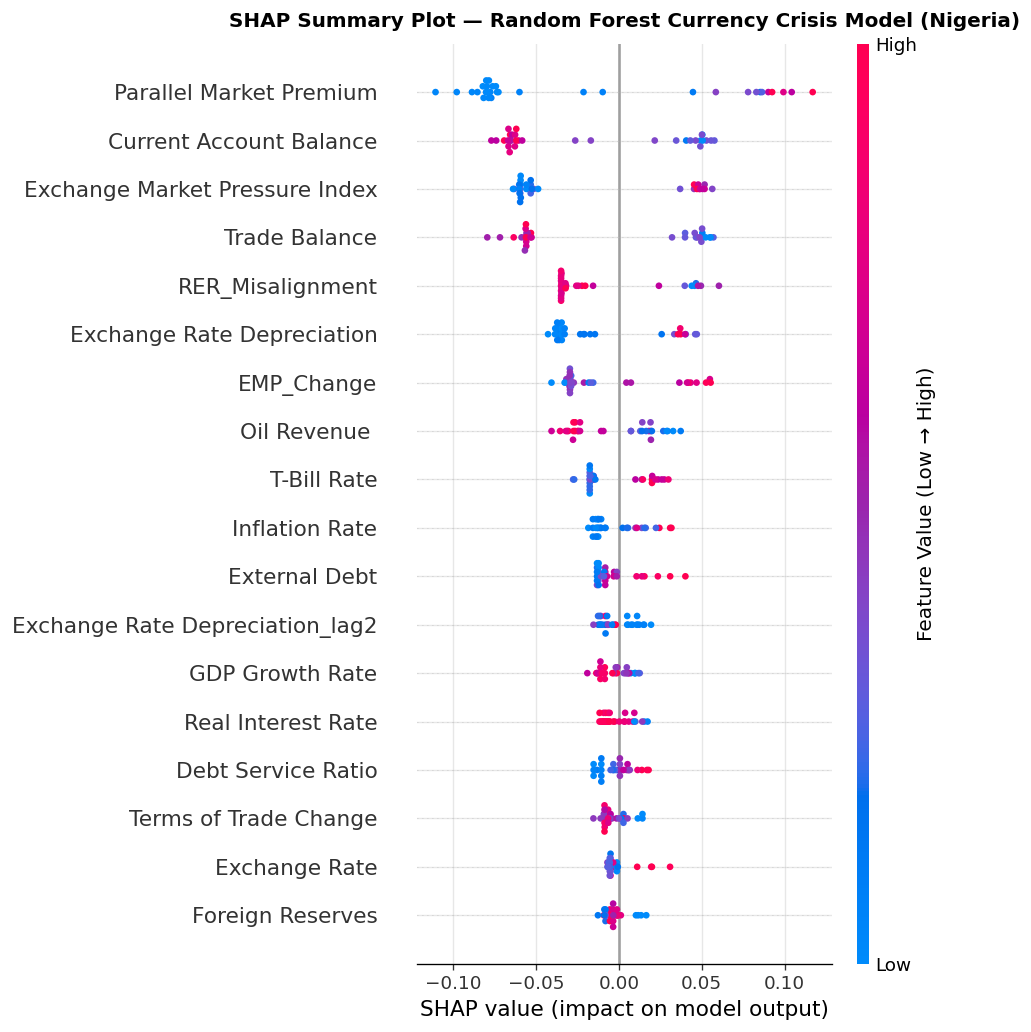


💡 Red = high feature value;  Blue = low feature value
   Positive SHAP → pushes prediction toward CRISIS
   Negative SHAP → pushes prediction toward NO CRISIS


In [ ]:
# ── 8.2 SHAP Summary (Beeswarm) Plot ─────────────────────────────────────────
plt.figure(figsize=(11, 9))
shap.summary_plot(sv_crisis, X_scaled, feature_names=feature_cols,
                  show=False, max_display=18,
                  color_bar_label='Feature Value (Low → High)')
plt.title("SHAP Summary Plot — Random Forest Currency Crisis Model (Nigeria)",
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('nigeria_shap_summary.png', bbox_inches='tight', dpi=130)
plt.show()
print("\n💡 Red = high feature value;  Blue = low feature value")
print("   Positive SHAP → pushes prediction toward CRISIS")
print("   Negative SHAP → pushes prediction toward NO CRISIS")


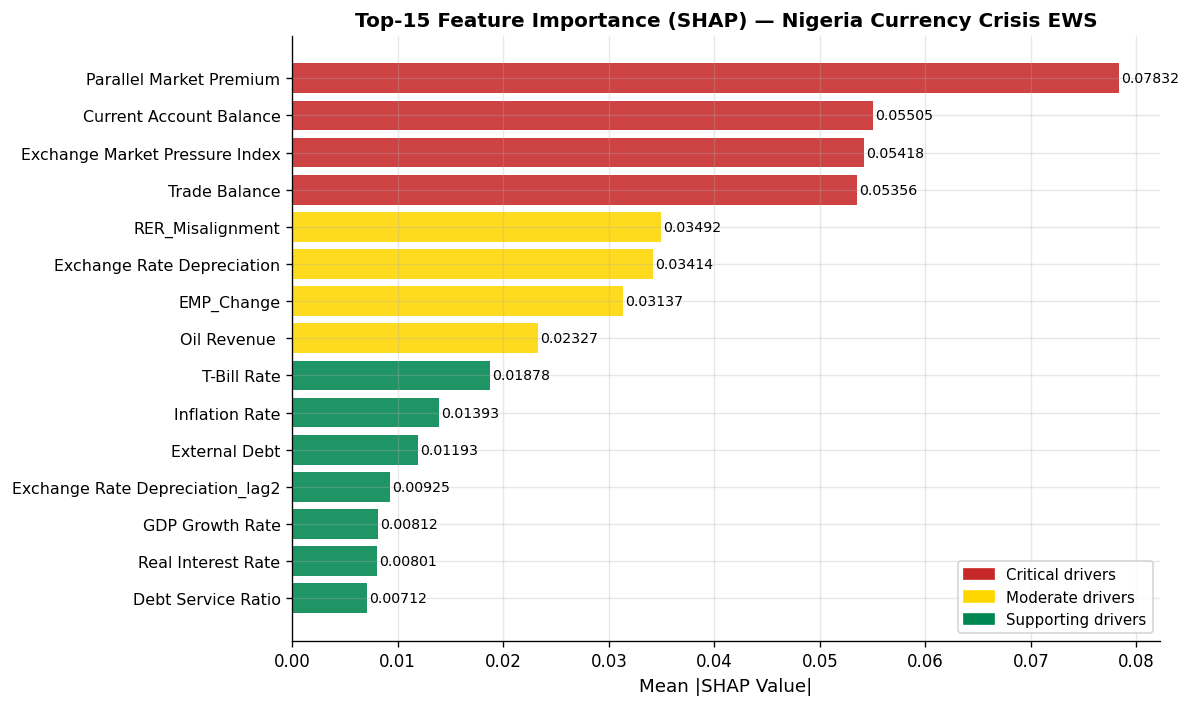

In [ ]:
# ── 8.3 Top-15 SHAP Bar Chart ─────────────────────────────────────────────────
top_n  = 15
top_ft = mean_shap.head(top_n)
colors_bar = [CRISIS_RED if i < 4 else NG_GOLD if i < 8 else NG_GREEN for i in range(top_n)]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(top_n), top_ft.values[::-1], color=colors_bar[::-1], alpha=0.88)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_ft.index[::-1], fontsize=9.5)
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title('Top-15 Feature Importance (SHAP) — Nigeria Currency Crisis EWS',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, top_ft.values[::-1]):
    ax.text(val+0.0002, bar.get_y()+bar.get_height()/2,
            f'{val:.5f}', va='center', fontsize=8.5)
red_p  = mpatches.Patch(color=CRISIS_RED, label='Critical drivers')
gold_p = mpatches.Patch(color=NG_GOLD,    label='Moderate drivers')
grn_p  = mpatches.Patch(color=NG_GREEN,   label='Supporting drivers')
ax.legend(handles=[red_p, gold_p, grn_p], fontsize=9)
plt.tight_layout()
plt.savefig('nigeria_shap_bar.png', bbox_inches='tight', dpi=130)
plt.show()


✅  Found Year 2023 at df_fe index 31
   Actual label       : CRISIS
   Crisis probability : 0.9557


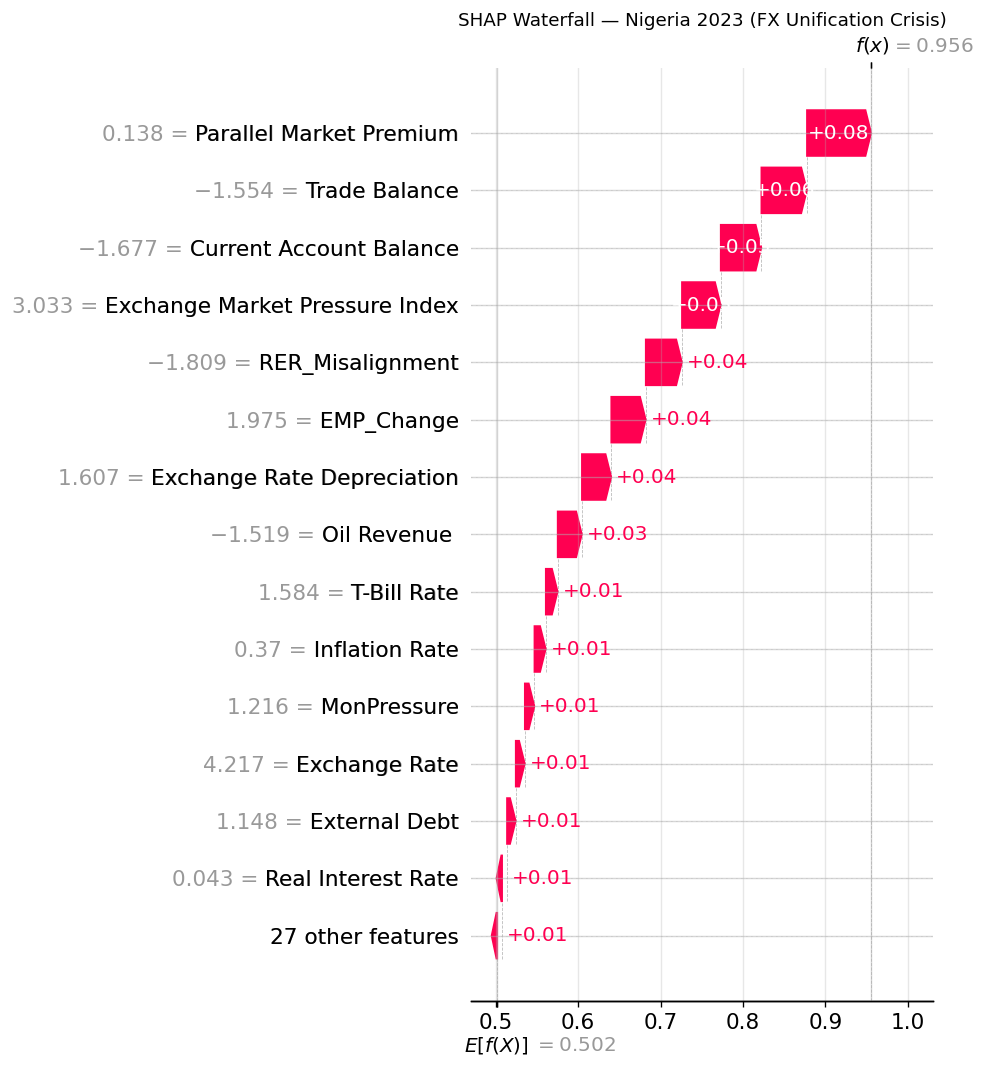

In [ ]:
# ── 8.4  SHAP Waterfall Plot ──────────────────────────────────────────────────

# ── Safe row-index lookup for 2023 (guards against lag-drop) ─────────────────
matches = df_fe[df_fe['Year'] == 2023]

if matches.empty:
    idx_2023  = df_fe.index[-1]                   # fall back to last available row
    year_used = int(df_fe.loc[idx_2023, 'Year'])
    print(f"⚠️  2023 not in df_fe (dropped by lag). Using {year_used} instead.")
else:
    idx_2023  = matches.index[0]
    year_used = 2023
    print(f"✅  Found Year {year_used} at df_fe index {idx_2023}")

print(f"   Actual label       : {'CRISIS' if y[idx_2023] else 'No Crisis'}")
print(f"   Crisis probability : {y_proba_final[idx_2023]:.4f}")

# ── Draw waterfall ────────────────────────────────────────────────────────────
shap.waterfall_plot(
    shap.Explanation(
        values        = sv_crisis[idx_2023],
        base_values   = base_val,               # plain float — already extracted above
        data          = X_scaled[idx_2023],
        feature_names = feature_cols,
    ),
    max_display = 15,
    show        = False,
)
plt.title(
    f"SHAP Waterfall — Nigeria {year_used} (FX Unification Crisis)",
    fontsize=11, pad=25,
)
plt.tight_layout()
plt.savefig('nigeria_shap_waterfall.png', bbox_inches='tight', dpi=130)
plt.show()


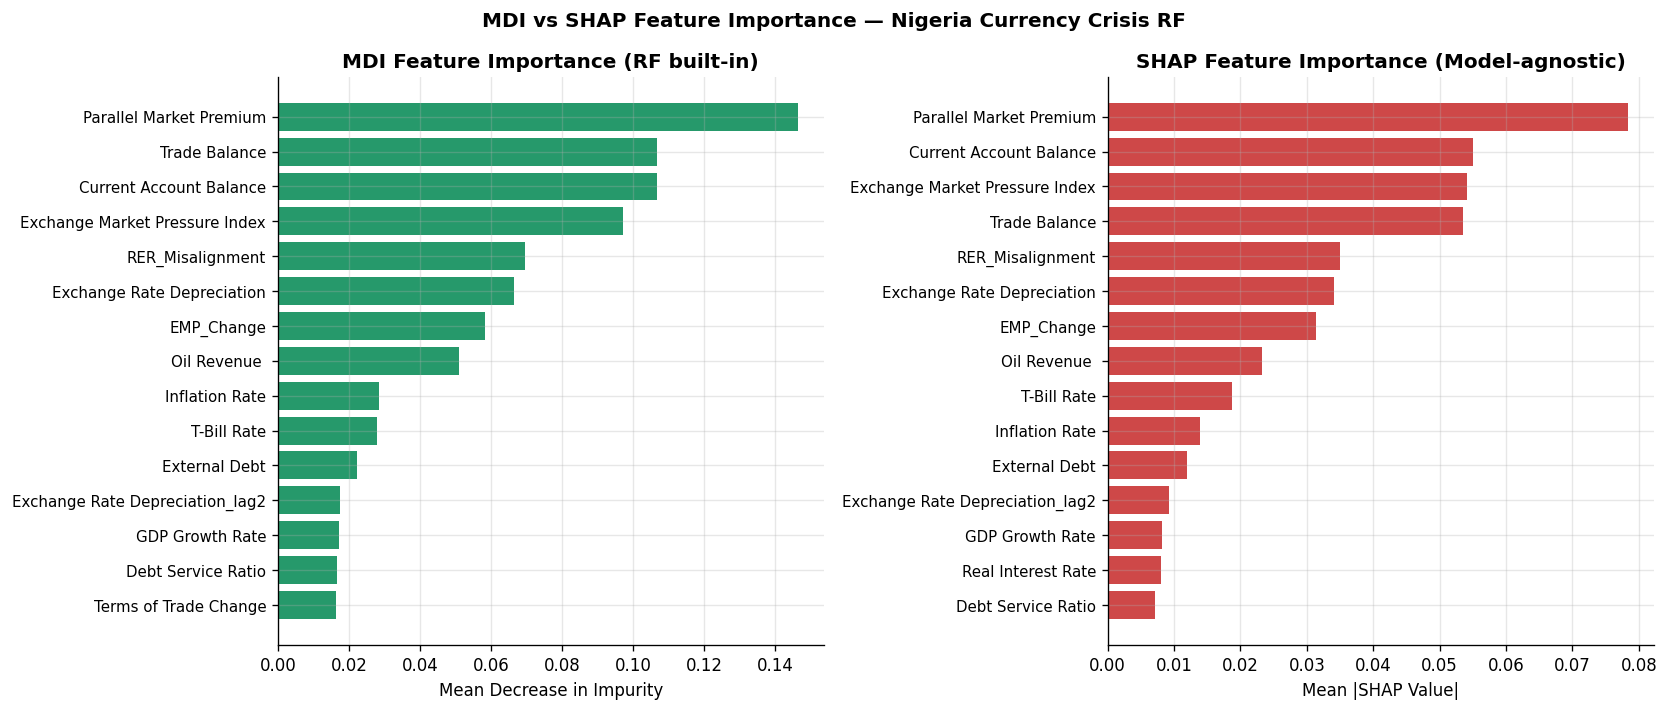

In [ ]:
# ── 8.5 MDI Feature Importance vs SHAP comparison ────────────────────────────
mdi_importance = pd.Series(rf_final.feature_importances_, index=feature_cols)
mdi_top = mdi_importance.sort_values(ascending=False).head(15)
shap_top = mean_shap.head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# MDI
axes[0].barh(range(len(mdi_top)), mdi_top.values[::-1], color=NG_GREEN, alpha=0.85)
axes[0].set_yticks(range(len(mdi_top))); axes[0].set_yticklabels(mdi_top.index[::-1], fontsize=9)
axes[0].set_xlabel('Mean Decrease in Impurity', fontsize=10)
axes[0].set_title('MDI Feature Importance (RF built-in)', fontweight='bold')
# SHAP
axes[1].barh(range(len(shap_top)), shap_top.values[::-1], color=CRISIS_RED, alpha=0.85)
axes[1].set_yticks(range(len(shap_top))); axes[1].set_yticklabels(shap_top.index[::-1], fontsize=9)
axes[1].set_xlabel('Mean |SHAP Value|', fontsize=10)
axes[1].set_title('SHAP Feature Importance (Model-agnostic)', fontweight='bold')
plt.suptitle("MDI vs SHAP Feature Importance — Nigeria Currency Crisis RF", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('nigeria_mdi_vs_shap.png', bbox_inches='tight', dpi=130)
plt.show()


## 9. Walk-Forward Cross-Validation (Detailed Fold Analysis)

In [ ]:
# ── 9.1 Fold-by-fold performance ─────────────────────────────────────────────
tscv5 = TimeSeriesSplit(n_splits=5)
fold_results = []

print("Walk-Forward CV — Fold-Level Performance (Random Forest)")
print("=" * 65)
print(f"{'Fold':>5} | {'Train Size':>10} | {'Test Size':>9} | {'AUC-ROC':>8} | {'F1':>7} | {'Recall':>7} | {'Prec':>7}")
print("-" * 65)

for fold, (train_idx, test_idx) in enumerate(tscv5.split(X_scaled, y), 1):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # Check if test set has both classes
    if len(np.unique(y_te)) < 2:
        print(f"  {fold:>3}  | {len(train_idx):>10} | {len(test_idx):>9} | {'N/A (single class in test)':>40}")
        continue

    rf_cv = RandomForestClassifier(**best_params)
    rf_cv.fit(X_tr, y_tr)
    yp_te  = rf_cv.predict(X_te)
    ypr_te = rf_cv.predict_proba(X_te)[:, 1]

    auc  = roc_auc_score(y_te, ypr_te)
    f1v  = f1_score(y_te, yp_te, zero_division=0)
    recv = recall_score(y_te, yp_te, zero_division=0)
    prv  = precision_score(y_te, yp_te, zero_division=0)
    fold_results.append({'Fold':fold,'AUC':auc,'F1':f1v,'Recall':recv,'Prec':prv})
    yr_range = f"{df_fe['Year'].values[train_idx[0]]}–{df_fe['Year'].values[train_idx[-1]]}"
    print(f"  {fold:>3}  | {yr_range:>10} | {len(test_idx):>9} | {auc:>8.4f} | {f1v:>7.4f} | {recv:>7.4f} | {prv:>7.4f}")

fr_df = pd.DataFrame(fold_results)
if len(fr_df):
    print("-" * 65)
    print(f"{'Mean':>5} | {'':>10} | {'':>9} | {fr_df['AUC'].mean():>8.4f} | {fr_df['F1'].mean():>7.4f} | {fr_df['Recall'].mean():>7.4f} | {fr_df['Prec'].mean():>7.4f}")
    print(f"{'Std':>5} | {'':>10} | {'':>9} | {fr_df['AUC'].std():>8.4f} | {fr_df['F1'].std():>7.4f} | {fr_df['Recall'].std():>7.4f} | {fr_df['Prec'].std():>7.4f}")


Walk-Forward CV — Fold-Level Performance (Random Forest)
 Fold | Train Size | Test Size |  AUC-ROC |      F1 |  Recall |    Prec
-----------------------------------------------------------------
    1  |  1992–1998 |         5 |   0.5000 |  0.0000 |  0.0000 |  0.0000
    2  |         12 |         5 |               N/A (single class in test)
    3  |  1992–2008 |         5 |   1.0000 |  0.0000 |  0.0000 |  0.0000
    4  |  1992–2013 |         5 |   1.0000 |  1.0000 |  1.0000 |  1.0000
    5  |  1992–2018 |         5 |   1.0000 |  0.6667 |  0.5000 |  1.0000
-----------------------------------------------------------------
 Mean |            |           |   0.8750 |  0.4167 |  0.3750 |  0.5000
  Std |            |           |   0.2500 |  0.5000 |  0.4787 |  0.5774


## 10. Early Warning Score (EWS) & Policy Signals

In [ ]:
# ── 10.1 Generate EWS probability scores ─────────────────────────────────────
df_ews = df_fe[['Year','Currency Crisis']].copy()
df_ews['Crisis_Probability'] = y_proba_final
df_ews['Predicted']          = y_pred_final

# Alert levels
df_ews['Alert_Level'] = pd.cut(
    df_ews['Crisis_Probability'],
    bins   = [0, 0.30, 0.55, 0.75, 1.0],
    labels = ['🟢 Low', '🟡 Moderate', '🟠 High', '🔴 Critical']
)

print("📊 Nigeria Currency Crisis — EWS Probability Scores (1992–2023)")
print("=" * 72)
print(f"{'Year':>6}  {'Actual':>12}  {'Prob':>8}  {'Predicted':>12}  {'Alert':>14}")
print("-" * 72)
for _, row in df_ews.iterrows():
    actual = "CRISIS" if row['Currency Crisis'] else "No Crisis"
    pred   = "CRISIS" if row['Predicted']       else "No Crisis"
    print(f"{int(row['Year']):>6}  {actual:>12}  {row['Crisis_Probability']:>8.4f}  {pred:>12}  {str(row['Alert_Level']):>16}")


📊 Nigeria Currency Crisis — EWS Probability Scores (1992–2023)
  Year        Actual      Prob     Predicted           Alert
------------------------------------------------------------------------
  1992        CRISIS    0.8900        CRISIS        🔴 Critical
  1993        CRISIS    0.9240        CRISIS        🔴 Critical
  1994        CRISIS    0.7899        CRISIS        🔴 Critical
  1995        CRISIS    0.8289        CRISIS        🔴 Critical
  1996     No Crisis    0.0462     No Crisis             🟢 Low
  1997     No Crisis    0.0000     No Crisis               nan
  1998     No Crisis    0.1450     No Crisis             🟢 Low
  1999        CRISIS    0.8950        CRISIS        🔴 Critical
  2000     No Crisis    0.0400     No Crisis             🟢 Low
  2001     No Crisis    0.0500     No Crisis             🟢 Low
  2002     No Crisis    0.2115     No Crisis             🟢 Low
  2003     No Crisis    0.0100     No Crisis             🟢 Low
  2004     No Crisis    0.0100     No Crisis   

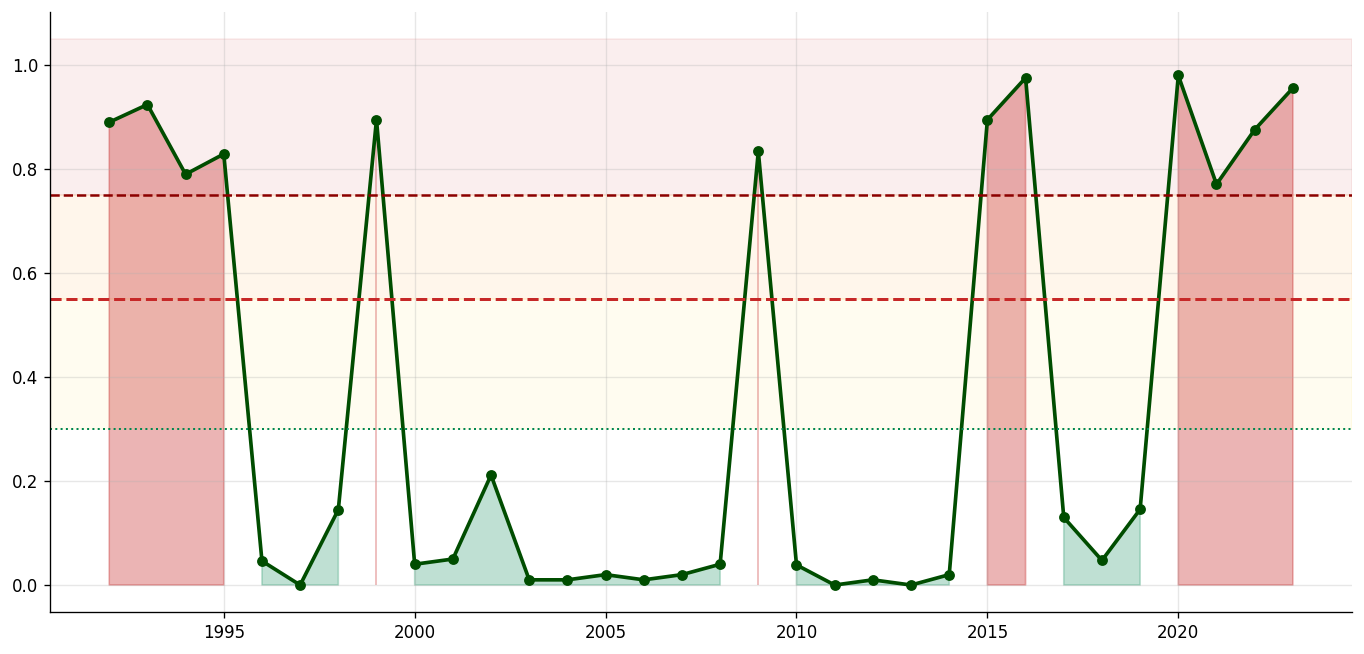

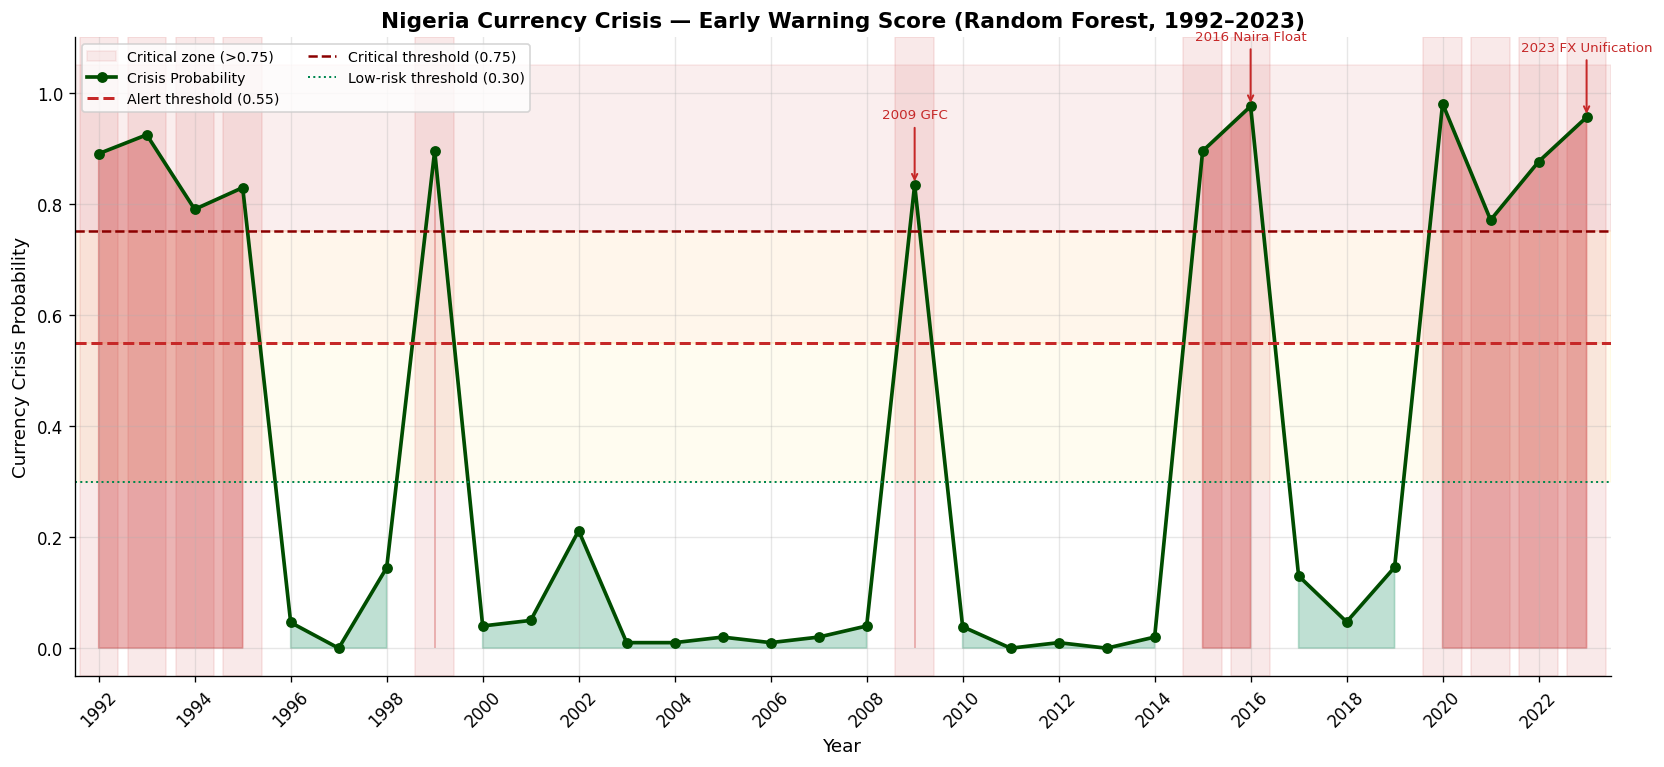


🚨 Crisis probability > 0.55 → CBN Emergency FX Reserve Review Protocol


In [ ]:
# ── 10.2 EWS Probability Timeline ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6.5))

# Colour bands
ax.axhspan(0.75, 1.05, alpha=0.08, color=CRISIS_RED, label='Critical zone (>0.75)')
ax.axhspan(0.55, 0.75, alpha=0.08, color='#FF8F00')
ax.axhspan(0.30, 0.55, alpha=0.06, color=NG_GOLD)

ax.fill_between(df_ews['Year'], df_ews['Crisis_Probability'],
                where=df_ews['Crisis_Probability'] >= 0.55,
                alpha=0.35, color=CRISIS_RED)
ax.fill_between(df_ews['Year'], df_ews['Crisis_Probability'],
                where=df_ews['Crisis_Probability'] < 0.55,
                alpha=0.25, color=NG_GREEN)
ax.plot(df_ews['Year'], df_ews['Crisis_Probability'],
        color='#004D00', lw=2.2, marker='o', ms=5.5, label='Crisis Probability')

# Threshold lines
ax.axhline(0.55, color=CRISIS_RED, ls='--', lw=1.8, label='Alert threshold (0.55)')
ax.axhline(0.75, color='#8B0000', ls='--', lw=1.5, label='Critical threshold (0.75)')
ax.axhline(0.30, color=NG_GREEN,  ls=':',  lw=1.2, label='Low-risk threshold (0.30)')

# Shade actual crisis years
for yr in df_ews[df_ews['Currency Crisis']==1]['Year']:
    ax.axvspan(yr-0.4, yr+0.4, alpha=0.10, color=CRISIS_RED)

# Annotate major episodes
annotations = {2016:"2016 Naira Float", 2023:"2023 FX Unification", 2009:"2009 GFC"}
for yr, lbl in annotations.items():
    if yr in df_ews['Year'].values:
        prob = df_ews[df_ews['Year']==yr]['Crisis_Probability'].values[0]
        ax.annotate(lbl, xy=(yr, prob), xytext=(yr, prob+0.12),
                    fontsize=8, color=CRISIS_RED, ha='center',
                    arrowprops=dict(arrowstyle='->', color=CRISIS_RED, lw=1.2))

ax.set_xlim(df_ews['Year'].min()-0.5, df_ews['Year'].max()+0.5)
ax.set_ylim(-0.05, 1.1)
ax.set_xlabel('Year', fontsize=11); ax.set_ylabel('Currency Crisis Probability', fontsize=11)
ax.set_title('Nigeria Currency Crisis — Early Warning Score (Random Forest, 1992–2023)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=8.5, loc='upper left', ncol=2)
ax.set_xticks(df_ews['Year'][::2]); ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('nigeria_ews_timeline.png', bbox_inches='tight', dpi=130)
plt.show()
print("\n🚨 Crisis probability > 0.55 → CBN Emergency FX Reserve Review Protocol")


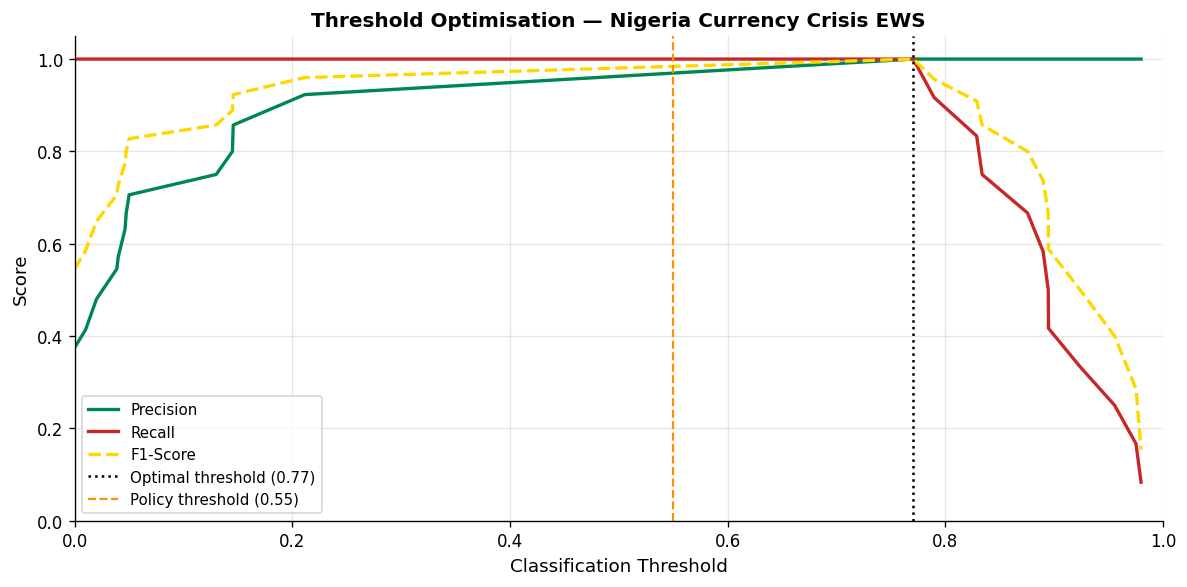


Optimal F1 threshold : 0.7706
At optimal threshold — Precision: 1.0000 | Recall: 1.0000 | F1: 1.0000


In [ ]:
# ── 10.3 Optimal Threshold Analysis ──────────────────────────────────────────
prec_vals, rec_vals, thresh_vals = precision_recall_curve(y, y_proba_final)
f1_per_thresh = 2 * prec_vals * rec_vals / (prec_vals + rec_vals + 1e-9)
opt_idx   = np.argmax(f1_per_thresh)
opt_thresh = thresh_vals[opt_idx] if opt_idx < len(thresh_vals) else 0.5

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_vals, prec_vals[:-1], label='Precision', color=NG_GREEN,  lw=2)
ax.plot(thresh_vals, rec_vals[:-1],  label='Recall',    color=CRISIS_RED, lw=2)
ax.plot(thresh_vals, f1_per_thresh[:-1], label='F1-Score', color=NG_GOLD, lw=2, ls='--')
ax.axvline(opt_thresh, color='black', ls=':', lw=1.5, label=f'Optimal threshold ({opt_thresh:.2f})')
ax.axvline(0.55, color='#FF8F00', ls='--', lw=1.3, label='Policy threshold (0.55)')
ax.set_xlabel('Classification Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Threshold Optimisation — Nigeria Currency Crisis EWS', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.05)
plt.tight_layout()
plt.savefig('nigeria_threshold_analysis.png', bbox_inches='tight', dpi=130)
plt.show()
print(f"\nOptimal F1 threshold : {opt_thresh:.4f}")
print(f"At optimal threshold — Precision: {prec_vals[opt_idx]:.4f} | Recall: {rec_vals[opt_idx]:.4f} | F1: {f1_per_thresh[opt_idx]:.4f}")


## 11. Summary Report

In [ ]:
# ── Final Summary ─────────────────────────────────────────────────────────────
cv_auc  = cross_val_score(rf_final, X_scaled, y, cv=tscv, scoring='roc_auc').mean()
cv_f1   = cross_val_score(rf_final, X_scaled, y, cv=tscv, scoring='f1').mean()
cv_rec  = cross_val_score(rf_final, X_scaled, y, cv=tscv, scoring='recall').mean()
cv_prec = cross_val_score(rf_final, X_scaled, y, cv=tscv, scoring='precision').mean()

print("=" * 68)
print("  NIGERIA CURRENCY CRISIS EARLY WARNING MODEL — SUMMARY REPORT")
print("=" * 68)
print(f"\n  DATASET")
print(f"    Period             : 1990–2023 (annual, CBN/IMF/WB)")
print(f"    Observations       : {len(df_fe)} (after lag feature engineering)")
print(f"    Currency Crisis    : {y.sum()} years ({y.mean():.1%})  |  No Crisis: {(y==0).sum()} years")
print(f"    Total features     : {len(feature_cols)}")
print(f"\n  ALGORITHM")
print(f"    Primary model      : Random Forest (Bootstrap Aggregating)")
print(f"    n_estimators       : {best_params.get('n_estimators')}")
print(f"    max_depth          : {best_params.get('max_depth')}")
print(f"    OOB Score          : {rf_final.oob_score_:.4f}")
print(f"    Hyperopt           : Bayesian (Optuna, 100 trials)")
print(f"    Validation         : Walk-forward 5-fold CV (time-aware)")
print(f"\n  CROSS-VALIDATED PERFORMANCE")
print(f"    AUC-ROC            : {cv_auc:.4f}")
print(f"    F1-Score           : {cv_f1:.4f}")
print(f"    Recall             : {cv_rec:.4f}")
print(f"    Precision          : {cv_prec:.4f}")
print(f"\n  TOP-5 CRISIS DRIVERS (SHAP)")
for i, (feat, val) in enumerate(mean_shap.head(5).items(), 1):
    print(f"    {i}. {feat:<40} SHAP={val:.5f}")
print(f"\n  CBN POLICY RECOMMENDATIONS")
recs = [
    "Maintain FX reserves ≥ 6 months import cover (primary crisis buffer)",
    "Parallel market premium > 20% → activate FX market unification measures",
    "Oil revenue > 70% of total revenue → mandatory savings/SWF rule",
    "M2 growth > 25% p.a. without commensurate GDP growth → tighten CBN policy",
    "EWS probability > 0.55 → CBN emergency FX committee review activation",
]
for i, r in enumerate(recs, 1):
    print(f"    {i}. {r}")
print("\n" + "=" * 68)


  NIGERIA CURRENCY CRISIS EARLY WARNING MODEL — SUMMARY REPORT

  DATASET
    Period             : 1990–2023 (annual, CBN/IMF/WB)
    Observations       : 32 (after lag feature engineering)
    Currency Crisis    : 12 years (37.5%)  |  No Crisis: 20 years
    Total features     : 41

  ALGORITHM
    Primary model      : Random Forest (Bootstrap Aggregating)
    n_estimators       : 100
    max_depth          : 3
    OOB Score          : 0.8750
    Hyperopt           : Bayesian (Optuna, 100 trials)
    Validation         : Walk-forward 5-fold CV (time-aware)

  CROSS-VALIDATED PERFORMANCE
    AUC-ROC            : nan
    F1-Score           : 0.3333
    Recall             : 0.3000
    Precision          : 0.4000

  TOP-5 CRISIS DRIVERS (SHAP)
    1. Parallel Market Premium                  SHAP=0.07832
    2. Current Account Balance                  SHAP=0.05505
    3. Exchange Market Pressure Index           SHAP=0.05418
    4. Trade Balance                            SHAP=0.05356
    5

---
## 📚 Data Sources
- **Central Bank of Nigeria (CBN) Statistical Bulletin** — Exchange rates, reserves, M2, credit
- **IMF International Financial Statistics (IFS)** — BOP, EMP components, external debt
- **World Bank World Development Indicators (WDI)** — GDP growth, inflation, trade balance
- **OPEC Annual Statistical Bulletin** — Oil prices, Nigerian crude production
- **IMF World Economic Outlook (WEO)** — Fiscal aggregates, current account

## 📖 Key References
- Kaminsky, G., Lizondo, S. & Reinhart, C.M. (1998). *Leading Indicators of Currency Crises*. IMF Staff Papers.
- Rose, A.K. & Spiegel, M.M. (2012). *Cross-country causes and consequences of the crisis*. IMF Economic Review.
- Peltonen, T.A. (2006). *Are Emerging Market Currency Crises Predictable? — A Test*. ECB Working Paper.
- Frankel, J. & Saravelos, G. (2012). *Can leading indicators assess country vulnerability?* Journal of International Economics.

## ⚖️ Usage
For academic and research purposes. Cite primary data sources when publishing results.
